# Phát Hiện Bất Thường Theo Luật Nghiệp Vụ dựa trên Session người dùng trong web thương mại điện tử

## RetailRocket E-Commerce Dataset

Dataset: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset

Đơn vị phân tích chính là `session_id`, được tạo từ `visitorid` và khoảng nghỉ 30 phút giữa hai sự kiện liên tiếp. Dataset không có nhãn bất thường thật, vì vậy nhãn `is_anomaly_rule` và `anomaly_types` là pseudo-label do nhóm thiết kế bằng luật nghiệp vụ.

## Hệ thống business rules và anomaly types

| Mã | Anomaly type | Mô tả nghiệp vụ | Dấu hiệu chính trong notebook |
| --- | --- | --- | --- |
| BR01 | Bot scraper | Session có hành vi duyệt tự động hoặc quét dữ liệu nhanh. | Nhiều event trong session hoặc tốc độ event/phút cao. |
| BR02 | Ghost buyer | Có giao dịch nhưng không có bước thêm giỏ trong cùng session. | `transaction > 0` và `addtocart = 0`. |
| BR03 | Click fraud | Xem nhiều sản phẩm nhưng không có ý định mua hoặc thêm giỏ. | Nhiều `view`, không có `addtocart`, không có `transaction`. |
| BR04 | Rapid-fire | Các thao tác diễn ra quá sát nhau, giống bot/script. | Có event liên tiếp dưới 1 giây hoặc tỉ lệ rapid-fire cao. |
| BR05 | Night crawler | Session hoạt động chủ yếu vào khung giờ đêm. | Tỉ lệ event 0h-5h cao và session đủ số event tối thiểu. |
| BR06 | Item hoarding | Thêm cùng một sản phẩm vào giỏ nhiều lần trong một session. | `max_same_item_atc` vượt ngưỡng. |
| BR07 | Session bomb | Session xem/quét quá nhiều item khác nhau. | `unique_items` cao. |
| BR08 | Sequence violation | Thứ tự hành vi bất thường: mua trước khi xem/thêm giỏ cùng item. | `transaction` xuất hiện trước `view/addtocart` của cùng item trong session. |
| BR09 | Transaction burst | Session có số lượng giao dịch cao bất thường. | `n_transaction` vượt ngưỡng. |
| BR10 | Cart abandonment | Thêm nhiều sản phẩm vào giỏ nhưng không giao dịch. | `n_addtocart` cao và `n_transaction = 0`. |
| BR11 | Repeated view spam | Xem lặp lại cùng một item quá nhiều lần. | `max_same_item_view` vượt ngưỡng. |
| BR12 | Category scanning | Quét nhiều nhóm danh mục sản phẩm trong một session. | `unique_categories` cao nếu dữ liệu category khả dụng. |

Các rule này dùng để gắn nhãn multi-label cho session. Một session có thể vừa là `Bot scraper`, vừa là `Rapid-fire`, vừa là `Session bomb`. Các thuật toán ML dùng pseudo-label này để so sánh/mô phỏng, không được diễn giải như nhãn gian lận thật.

Phần mô hình được chia thành `train`, `validation`, `test`. Validation dùng để chọn threshold dự đoán; test dùng để báo cáo kết quả cuối.


## Phân công thuật toán

| Thành viên | Thuật toán | Loại | Vai trò trong đồ án |
| --- | --- | --- | --- |
| Đình Tuấn | XGBoost | Phân loại có giám sát | Mô hình boosting mạnh, xử lý dữ liệu phi tuyến và mất cân bằng lớp |
| Lê Văn Anh | Decision Tree | Phân loại có giám sát | Mô hình dễ giải thích, minh họa được luật quyết định |
| Tuấn Anh | Random Forest | Phân loại có giám sát | Ensemble nhiều cây, ổn định hơn cây đơn và có feature importance |
| Thủy | LightGBM | Phân loại có giám sát | Gradient boosting leaf-wise, nhanh và hiệu quả trên dữ liệu dạng bảng; so sánh thêm với XGBoost |
| Đức Anh | Isolation Forest | Phát hiện bất thường không giám sát | Thuật toán chuyên biệt cho anomaly detection |

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    from xgboost import XGBClassifier
except Exception as exc:
    raise ImportError(
        "Chua load duoc XGBoost. Cai Python package bang `.venv/bin/python -m pip install xgboost`; "
        "tren macOS can them OpenMP runtime bang `brew install libomp`."
    ) from exc

try:
    from lightgbm import LGBMClassifier
except Exception as exc:
    raise ImportError(
        "Chua load duoc LightGBM. Cai Python package bang `.venv/bin/python -m pip install lightgbm`; "
        "tren macOS neu gap loi OpenMP thi cai `brew install libomp`."
    ) from exc

warnings.filterwarnings('ignore')

RANDOM_STATE = 10
OUTPUT_DIR = Path('.')
DATA_PATH = Path('./data/events.csv')
SESSION_GAP_SEC = 30 * 60

MAX_SUPERVISED_ROWS = 300_000
IFOREST_TRAIN_ROWS = 250_000
PLOT_SAMPLE_ROWS = 30_000

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook')
COLORS = {
    'normal': '#2E7D32',
    'anomaly': '#C62828',
    'warning': '#EF6C00',
    'primary': '#1565C0',
    'secondary': '#6A1B9A',
    'dark': '#263238',
    'muted': '#607D8B',
}

print('Thu vien va cau hinh da san sang')

Thu vien va cau hinh da san sang


## 2. Tải dữ liệu, tiền xử lý và tạo session

Session được định nghĩa bằng khoảng nghỉ 30 phút giữa hai event liên tiếp của cùng `visitorid`.

In [2]:
print('Dang tai du lieu events.csv...')
events = pd.read_csv(DATA_PATH)

required_cols = {'timestamp', 'visitorid', 'event', 'itemid', 'transactionid'}
missing_cols = required_cols.difference(events.columns)
if missing_cols:
    raise ValueError(f'Thieu cot bat buoc: {sorted(missing_cols)}')

before_dedup = len(events)
events = events.drop_duplicates().reset_index(drop=True)
duplicate_count = before_dedup - len(events)

events = events[events['event'].isin(['view', 'addtocart', 'transaction'])].copy()

events['datetime'] = pd.to_datetime(events['timestamp'], unit='ms')
events['date'] = events['datetime'].dt.date
events['hour'] = events['datetime'].dt.hour
events['dayofweek'] = events['datetime'].dt.dayofweek

events = events.sort_values(['visitorid', 'timestamp', 'event', 'itemid']).reset_index(drop=True)
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['time_diff_sec'] = (events['timestamp'] - events['prev_timestamp']) / 1000

new_session = events['time_diff_sec'].isna() | (events['time_diff_sec'] > SESSION_GAP_SEC)
events['session_number'] = new_session.groupby(events['visitorid']).cumsum().astype('int32')
events['session_id'] = events['visitorid'].astype(str) + '_S' + events['session_number'].astype(str)

events['prev_session_timestamp'] = events.groupby('session_id')['timestamp'].shift(1)
events['time_diff_session_sec'] = (events['timestamp'] - events['prev_session_timestamp']) / 1000

session_count = events['session_id'].nunique()
print(f'So dong duplicate da xoa: {duplicate_count:,}')
print(f'Tong so su kien sau tien xu ly: {len(events):,}')
print(f'So visitor duy nhat: {events["visitorid"].nunique():,}')
print(f'So session tao ra: {session_count:,}')
print(f'Trung binh event/session: {len(events) / session_count:.2f}')
print(f'Thoi gian: {events["datetime"].min()} -> {events["datetime"].max()}')
print('\nPhan phoi event:')
display(events['event'].value_counts().rename_axis('event').reset_index(name='count'))

Dang tai du lieu events.csv...
So dong duplicate da xoa: 460
Tong so su kien sau tien xu ly: 2,755,641
So visitor duy nhat: 1,407,580
So session tao ra: 1,761,675
Trung binh event/session: 1.56
Thoi gian: 2015-05-03 03:00:04.384000 -> 2015-09-18 02:59:47.788000

Phan phoi event:


,event,count
0,view,2664218
1,addtocart,68966
2,transaction,22457


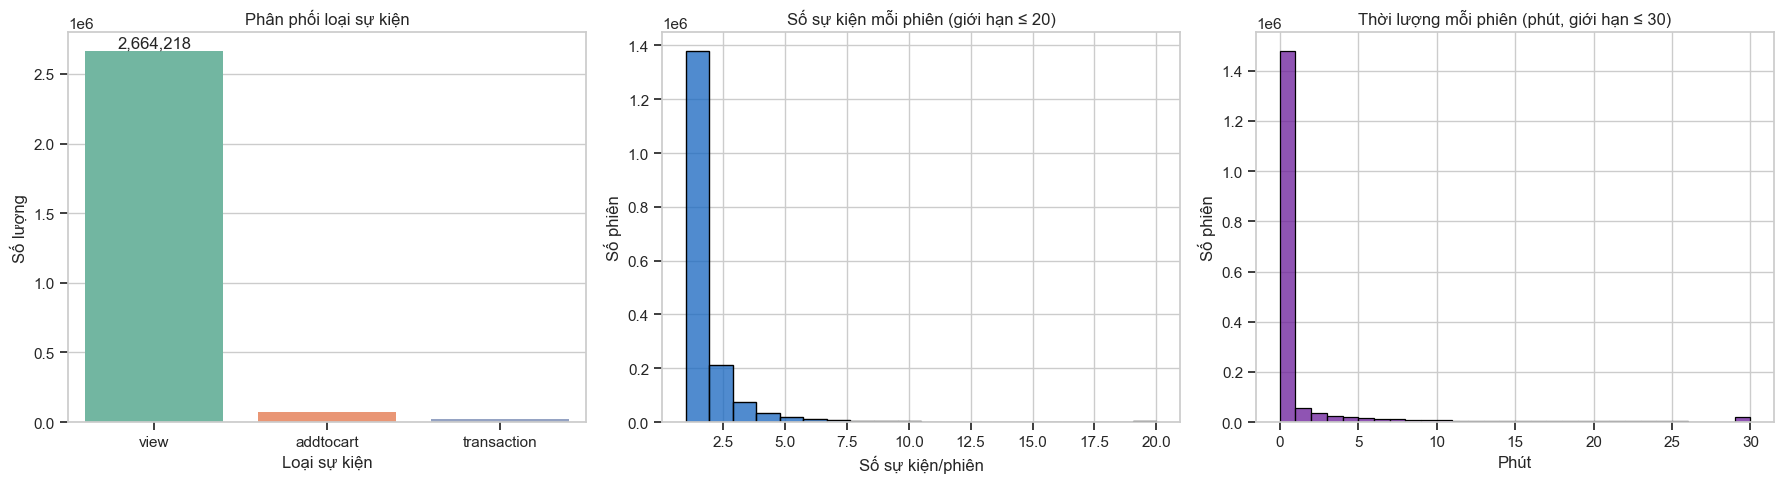

In [3]:
session_sizes = events.groupby('session_id').size()
session_duration = (events.groupby('session_id')['timestamp'].max() - events.groupby('session_id')['timestamp'].min()) / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = events['event'].value_counts().index
sns.countplot(data=events, x='event', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Phân phối loại sự kiện')
axes[0].set_xlabel('Loại sự kiện')
axes[0].set_ylabel('Số lượng')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}')

sns.histplot(session_sizes.clip(upper=20), bins=20, color=COLORS['primary'], ax=axes[1])
axes[1].set_title('Số sự kiện mỗi phiên (giới hạn ≤ 20)')
axes[1].set_xlabel('Số sự kiện/phiên')
axes[1].set_ylabel('Số phiên')

sns.histplot((session_duration / 60).clip(upper=30), bins=30, color=COLORS['secondary'], ax=axes[2])
axes[2].set_title('Thời lượng mỗi phiên (phút, giới hạn ≤ 30)')
axes[2].set_xlabel('Phút')
axes[2].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_session_distribution.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Xây dựng session behavior profile

Mỗi dòng của bảng profile tương ứng với một `session_id`. `visitorid` chỉ còn là metadata để truy vết người dùng.

In [4]:
print('Dang xay dung session behavior profile...')
df = events.copy()
g = df.groupby('session_id', sort=False)

profile = pd.DataFrame(index=g.size().index)
profile.index.name = 'session_id'
profile['visitorid'] = g['visitorid'].first().astype('int64')
profile['session_number'] = g['session_number'].first().astype('int32')
profile['session_start'] = g['datetime'].min()
profile['session_end'] = g['datetime'].max()
profile['session_start_hour'] = profile['session_start'].dt.hour
profile['session_dayofweek'] = profile['session_start'].dt.dayofweek
profile['total_events'] = g.size().astype('int32')
profile['unique_items'] = g['itemid'].nunique().astype('int32')
profile['active_hours'] = g['hour'].nunique().astype('int16')
profile['session_duration_sec'] = ((g['timestamp'].max() - g['timestamp'].min()) / 1000).astype('float32')

event_counts = df.groupby(['session_id', 'event']).size().unstack(fill_value=0)
event_counts.columns = [f'n_{col}' for col in event_counts.columns]
for col in ['n_view', 'n_addtocart', 'n_transaction']:
    if col not in event_counts.columns:
        event_counts[col] = 0
profile = profile.join(event_counts[['n_view', 'n_addtocart', 'n_transaction']].astype('int32'))
profile['unique_event_types'] = (profile[['n_view', 'n_addtocart', 'n_transaction']] > 0).sum(axis=1).astype('int8')

event_probs = event_counts[['n_view', 'n_addtocart', 'n_transaction']].div(profile['total_events'].clip(lower=1), axis=0)
profile['event_type_entropy'] = (-(event_probs.replace(0, np.nan) * np.log2(event_probs.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

hour_counts = df.groupby(['session_id', 'hour']).size().unstack(fill_value=0)
hour_probs = hour_counts.div(hour_counts.sum(axis=1).clip(lower=1), axis=0)
profile['hour_entropy'] = (-(hour_probs.replace(0, np.nan) * np.log2(hour_probs.replace(0, np.nan))).sum(axis=1)).fillna(0).astype('float32')

time_diffs = df.dropna(subset=['time_diff_session_sec'])
speed_stats = time_diffs.groupby('session_id')['time_diff_session_sec'].agg(
    min_interval_sec='min',
    mean_interval_sec='mean',
    median_interval_sec='median',
    std_interval_sec='std',
    max_interval_sec='max',
)
profile = profile.join(speed_stats).fillna({
    'min_interval_sec': 0,
    'mean_interval_sec': 0,
    'median_interval_sec': 0,
    'std_interval_sec': 0,
    'max_interval_sec': 0,
})
interval_cols = ['min_interval_sec', 'mean_interval_sec', 'median_interval_sec', 'std_interval_sec', 'max_interval_sec']
profile[interval_cols] = profile[interval_cols].astype('float32')

profile['rapid_fire_count'] = time_diffs[time_diffs['time_diff_session_sec'] < 1].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['night_events'] = df[df['hour'].between(0, 5)].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['peak_events'] = df[df['hour'].between(9, 21)].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')
profile['weekend_events'] = df[df['dayofweek'].isin([5, 6])].groupby('session_id').size().reindex(profile.index, fill_value=0).astype('int16')

view_events = df[df['event'] == 'view']
if len(view_events) > 0:
    max_same_item_view = view_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    profile['max_same_item_view'] = max_same_item_view.reindex(profile.index, fill_value=0).astype('int16')
else:
    profile['max_same_item_view'] = 0

atc_events = df[df['event'] == 'addtocart']
if len(atc_events) > 0:
    max_same_item_atc = atc_events.groupby(['session_id', 'itemid']).size().groupby('session_id').max()
    profile['max_same_item_atc'] = max_same_item_atc.reindex(profile.index, fill_value=0).astype('int16')
else:
    profile['max_same_item_atc'] = 0

profile['duration_min'] = (profile['session_duration_sec'] / 60).clip(lower=1).astype('float32')
profile['events_per_minute'] = (profile['total_events'] / profile['duration_min']).astype('float32')
profile['view_rate'] = (profile['n_view'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['atc_rate'] = (profile['n_addtocart'] / profile['n_view'].clip(lower=1)).astype('float32')
profile['buy_rate'] = (profile['n_transaction'] / profile['n_view'].clip(lower=1)).astype('float32')
profile['night_ratio'] = (profile['night_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['peak_ratio'] = (profile['peak_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['weekend_ratio'] = (profile['weekend_events'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['rapid_ratio'] = (profile['rapid_fire_count'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['items_per_event'] = (profile['unique_items'] / profile['total_events'].clip(lower=1)).astype('float32')
profile['view_to_cart_ratio'] = (profile['n_view'] / profile['n_addtocart'].clip(lower=1)).astype('float32')
profile['cart_to_transaction_ratio'] = (profile['n_addtocart'] / profile['n_transaction'].clip(lower=1)).astype('float32')

# Optional category features from RetailRocket item properties.
profile['unique_categories'] = 0
profile['unique_parent_categories'] = 0
try:
    item_props_1 = pd.read_csv('./data/item_properties_part1.csv', usecols=['itemid', 'property', 'value'])
    item_props_2 = pd.read_csv('./data/item_properties_part2.csv', usecols=['itemid', 'property', 'value'])
    item_categories = pd.concat([item_props_1, item_props_2], ignore_index=True)
    item_categories = item_categories[item_categories['property'].astype(str) == 'categoryid'][['itemid', 'value']]
    item_categories['categoryid'] = pd.to_numeric(item_categories['value'], errors='coerce')
    item_categories = item_categories.dropna(subset=['categoryid']).drop_duplicates('itemid')
    item_categories['categoryid'] = item_categories['categoryid'].astype('int64')

    category_tree = pd.read_csv('./data/category_tree.csv')
    category_parent = category_tree[['categoryid', 'parentid']].drop_duplicates('categoryid')
    item_categories = item_categories.merge(category_parent, on='categoryid', how='left')

    session_items = df[['session_id', 'itemid']].drop_duplicates()
    session_items = session_items.merge(item_categories[['itemid', 'categoryid', 'parentid']], on='itemid', how='left')
    profile['unique_categories'] = session_items.groupby('session_id')['categoryid'].nunique().reindex(profile.index, fill_value=0).astype('int16')
    profile['unique_parent_categories'] = session_items.groupby('session_id')['parentid'].nunique().reindex(profile.index, fill_value=0).astype('int16')
    print('Da bo sung category features tu item_properties va category_tree')
except Exception as exc:
    print(f'Bo qua category features vi khong load duoc item properties: {exc}')

print(f'Session profile shape: {profile.shape}')
print(f'Session_id unique: {profile.index.is_unique}')
display(profile.head())

Dang xay dung session behavior profile...
Da bo sung category features tu item_properties va category_tree
Session profile shape: (1761675, 41)
Session_id unique: True


,visitorid,session_number,session_start,session_end,session_start_hour,session_dayofweek,total_events,unique_items,active_hours,session_duration_sec,...,buy_rate,night_ratio,peak_ratio,weekend_ratio,rapid_ratio,items_per_event,view_to_cart_ratio,cart_to_transaction_ratio,unique_categories,unique_parent_categories
session_id,,,,,,,,,,,,,,,,,,,,,
0_S1,0,1,2015-09-11 20:49:49.439,2015-09-11 20:55:17.175,20,4,3,3,1,327.735992,...,0.0,0.0,1.0,0.0,0.0,1.0,3.0,0.0,3,2
1_S1,1,1,2015-08-13 17:46:06.444,2015-08-13 17:46:06.444,17,3,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1,1
2_S1,2,1,2015-08-07 17:51:44.567,2015-08-07 18:20:57.845,17,4,8,4,2,1753.277954,...,0.0,0.0,1.0,0.0,0.0,0.5,8.0,0.0,2,1
3_S1,3,1,2015-08-01 07:10:35.296,2015-08-01 07:10:35.296,7,5,1,1,1,0.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1,1
4_S1,4,1,2015-09-15 21:24:27.167,2015-09-15 21:24:27.167,21,1,1,1,1,0.000000,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0,0


In [5]:
summary_cols = [
    'total_events', 'unique_items', 'unique_categories', 'unique_parent_categories',
    'session_duration_sec', 'events_per_minute', 'n_view', 'n_addtocart', 'n_transaction',
    'rapid_fire_count', 'rapid_ratio', 'night_ratio', 'max_same_item_view', 'max_same_item_atc',
    'event_type_entropy', 'hour_entropy',
]
profile_summary = profile[summary_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
print('Thong ke cac dac trung session chinh:')
display(profile_summary)

Thong ke cac dac trung session chinh:


,count,mean,std,min,50%,75%,90%,95%,99%,max
total_events,1761675.0,1.564216,2.599172,1.000000,1.0,1.0,2.000000,4.00000,9.000000,417.000000
unique_items,1761675.0,1.332739,1.784379,1.000000,1.0,1.0,2.000000,3.00000,6.000000,389.000000
unique_categories,1761675.0,0.964344,0.892530,0.000000,1.0,1.0,1.000000,1.00000,3.000000,114.000000
unique_parent_categories,1761675.0,0.942344,0.755826,0.000000,1.0,1.0,1.000000,1.00000,2.000000,79.000000
session_duration_sec,1761675.0,105.243446,499.529755,0.000000,0.0,0.0,213.162402,624.14751,1792.538149,43704.246094
events_per_minute,1761675.0,1.039757,0.440438,0.048184,1.0,1.0,1.116754,2.00000,3.000000,29.099926
n_view,1761675.0,1.512321,2.352375,0.000000,1.0,1.0,2.000000,4.00000,8.000000,417.000000
n_addtocart,1761675.0,0.039148,0.397012,0.000000,0.0,0.0,0.000000,0.00000,1.000000,114.000000
n_transaction,1761675.0,0.012748,0.207124,0.000000,0.0,0.0,0.000000,0.00000,0.000000,59.000000
rapid_fire_count,1761675.0,0.009295,0.181702,0.000000,0.0,0.0,0.000000,0.00000,0.000000,66.000000


## 4. Business rules và multi-label anomaly tagging theo session

Các luật gắn nhãn hành vi đáng nghi ở cấp session. Một session có thể mang nhiều anomaly type cùng lúc.

In [6]:
# Preset improved_session_rules: ket hop rule hien tai voi cac rule hay tu thuy.ipynb.
# Muc tieu: giu ti le anomaly du mau cho phan tich, nhung van co y nghia nghiep vu.
THRESHOLDS = {
    'BR01_min_events_bot': 12,
    'BR01_min_events_per_minute': 8,
    'BR01_min_events_for_speed': 5,
    'BR03_min_views_for_click_fraud': 6,
    'BR04_rapid_fire_count': 1,
    'BR04_rapid_fire_ratio': 0.20,
    'BR04_min_events_for_rapid': 3,
    'BR05_night_ratio': 0.75,
    'BR05_min_events_for_night': 4,
    'BR06_max_same_item_atc': 1,
    'BR07_min_unique_items_session_bomb': 12,
    'BR09_min_transactions_burst': 3,
    'BR10_min_addtocart_abandonment': 10,
    'BR11_max_same_item_view': 20,
    'BR12_min_unique_categories': 20,
}

anomalies = profile.copy()

anomalies['flag_BR01_bot_scraper'] = (
    (anomalies['total_events'] >= THRESHOLDS['BR01_min_events_bot'])
    | (
        (anomalies['events_per_minute'] >= THRESHOLDS['BR01_min_events_per_minute'])
        & (anomalies['total_events'] >= THRESHOLDS['BR01_min_events_for_speed'])
    )
).astype(int)

anomalies['flag_BR02_ghost_buyer'] = (
    (anomalies['n_transaction'] > 0) & (anomalies['n_addtocart'] == 0)
).astype(int)

anomalies['flag_BR03_click_fraud'] = (
    (anomalies['n_view'] >= THRESHOLDS['BR03_min_views_for_click_fraud'])
    & (anomalies['n_addtocart'] == 0)
    & (anomalies['n_transaction'] == 0)
).astype(int)

anomalies['flag_BR04_rapid_fire'] = (
    (
        (anomalies['rapid_fire_count'] >= THRESHOLDS['BR04_rapid_fire_count'])
        | (anomalies['rapid_ratio'] >= THRESHOLDS['BR04_rapid_fire_ratio'])
    )
    & (anomalies['total_events'] >= THRESHOLDS['BR04_min_events_for_rapid'])
).astype(int)

anomalies['flag_BR05_night_crawler'] = (
    (anomalies['night_ratio'] >= THRESHOLDS['BR05_night_ratio'])
    & (anomalies['total_events'] >= THRESHOLDS['BR05_min_events_for_night'])
).astype(int)

anomalies['flag_BR06_item_hoarding'] = (
    anomalies['max_same_item_atc'] > THRESHOLDS['BR06_max_same_item_atc']
).astype(int)

anomalies['flag_BR07_session_bomb'] = (
    anomalies['unique_items'] >= THRESHOLDS['BR07_min_unique_items_session_bomb']
).astype(int)

# BR08: transaction xuat hien truoc view/addtocart cung item trong chinh session.
interaction_event = df['event'].isin(['view', 'addtocart']).astype('int8')
prior_item_interactions = interaction_event.groupby([df['session_id'], df['itemid']]).cumsum()
sequence_violation_sessions = df.loc[
    (df['event'] == 'transaction') & (prior_item_interactions == 0),
    'session_id',
].unique()
anomalies['flag_BR08_sequence_violation'] = anomalies.index.isin(sequence_violation_sessions).astype(int)

anomalies['flag_BR09_transaction_burst'] = (
    anomalies['n_transaction'] >= THRESHOLDS['BR09_min_transactions_burst']
).astype(int)

anomalies['flag_BR10_cart_abandonment'] = (
    (anomalies['n_addtocart'] >= THRESHOLDS['BR10_min_addtocart_abandonment'])
    & (anomalies['n_transaction'] == 0)
).astype(int)

anomalies['flag_BR11_repeated_view_spam'] = (
    anomalies['max_same_item_view'] >= THRESHOLDS['BR11_max_same_item_view']
).astype(int)

anomalies['flag_BR12_category_scanning'] = (
    anomalies['unique_categories'] >= THRESHOLDS['BR12_min_unique_categories']
).astype(int)

anomaly_type_map = {
    'flag_BR01_bot_scraper': 'Bot scraper',
    'flag_BR02_ghost_buyer': 'Ghost buyer',
    'flag_BR03_click_fraud': 'Click fraud',
    'flag_BR04_rapid_fire': 'Rapid-fire',
    'flag_BR05_night_crawler': 'Night crawler',
    'flag_BR06_item_hoarding': 'Item hoarding',
    'flag_BR07_session_bomb': 'Session bomb',
    'flag_BR08_sequence_violation': 'Sequence violation',
    'flag_BR09_transaction_burst': 'Transaction burst',
    'flag_BR10_cart_abandonment': 'Cart abandonment',
    'flag_BR11_repeated_view_spam': 'Repeated view spam',
    'flag_BR12_category_scanning': 'Category scanning',
}

flag_cols = list(anomaly_type_map.keys())
anomalies['total_flags'] = anomalies[flag_cols].sum(axis=1)
anomalies['is_anomaly_rule'] = (anomalies['total_flags'] > 0).astype(int)
anomalies['is_anomaly'] = anomalies['is_anomaly_rule']

flag_matrix = anomalies[flag_cols].to_numpy(dtype=bool)
anomaly_type_labels = np.array(list(anomaly_type_map.values()), dtype=object)
anomalies['anomaly_type_count'] = flag_matrix.sum(axis=1).astype(int)
anomalies['anomaly_types'] = [
    ', '.join(anomaly_type_labels[row_flags].tolist()) if row_flags.any() else 'Normal'
    for row_flags in flag_matrix
]

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags')
if not (anomalies.loc[anomalies['is_anomaly'] == 0, 'anomaly_types'] == 'Normal').all():
    raise ValueError('Session binh thuong phai co anomaly_types = Normal')

rule_summary = (
    anomalies[flag_cols]
    .sum()
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'flag'})
)
rule_summary['anomaly_type'] = rule_summary['flag'].map(anomaly_type_map)
rule_summary['percent_sessions'] = rule_summary['count'] / len(anomalies) * 100
rule_summary = rule_summary[['flag', 'anomaly_type', 'count', 'percent_sessions']].sort_values('count', ascending=False)
anomaly_type_breakdown = rule_summary[['anomaly_type', 'count', 'percent_sessions']].copy()

session_anomaly_tags = anomalies[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

print('Nguong luat nghiep vu session-level:')
for key, value in THRESHOLDS.items():
    print(f'- {key}: {value}')

print(f'\nSo session bat thuong theo luat: {anomalies["is_anomaly_rule"].sum():,} / {len(anomalies):,} '
      f'({anomalies["is_anomaly_rule"].mean() * 100:.2f}%)')
display(rule_summary)
print('\nVi du multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))

Nguong luat nghiep vu session-level:
- BR01_min_events_bot: 12
- BR01_min_events_per_minute: 8
- BR01_min_events_for_speed: 5
- BR03_min_views_for_click_fraud: 6
- BR04_rapid_fire_count: 1
- BR04_rapid_fire_ratio: 0.2
- BR04_min_events_for_rapid: 3
- BR05_night_ratio: 0.75
- BR05_min_events_for_night: 4
- BR06_max_same_item_atc: 1
- BR07_min_unique_items_session_bomb: 12
- BR09_min_transactions_burst: 3
- BR10_min_addtocart_abandonment: 10
- BR11_max_same_item_view: 20
- BR12_min_unique_categories: 20

So session bat thuong theo luat: 61,849 / 1,761,675 (3.51%)


,flag,anomaly_type,count,percent_sessions
2,flag_BR03_click_fraud,Click fraud,31213,1.771780
4,flag_BR05_night_crawler,Night crawler,30130,1.710304
0,flag_BR01_bot_scraper,Bot scraper,10884,0.617821
3,flag_BR04_rapid_fire,Rapid-fire,8052,0.457065
6,flag_BR07_session_bomb,Session bomb,5112,0.290178
5,flag_BR06_item_hoarding,Item hoarding,3212,0.182326
1,flag_BR02_ghost_buyer,Ghost buyer,2365,0.134247
7,flag_BR08_sequence_violation,Sequence violation,1573,0.089290
8,flag_BR09_transaction_burst,Transaction burst,1558,0.088439
11,flag_BR12_category_scanning,Category scanning,628,0.035648



Vi du multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0


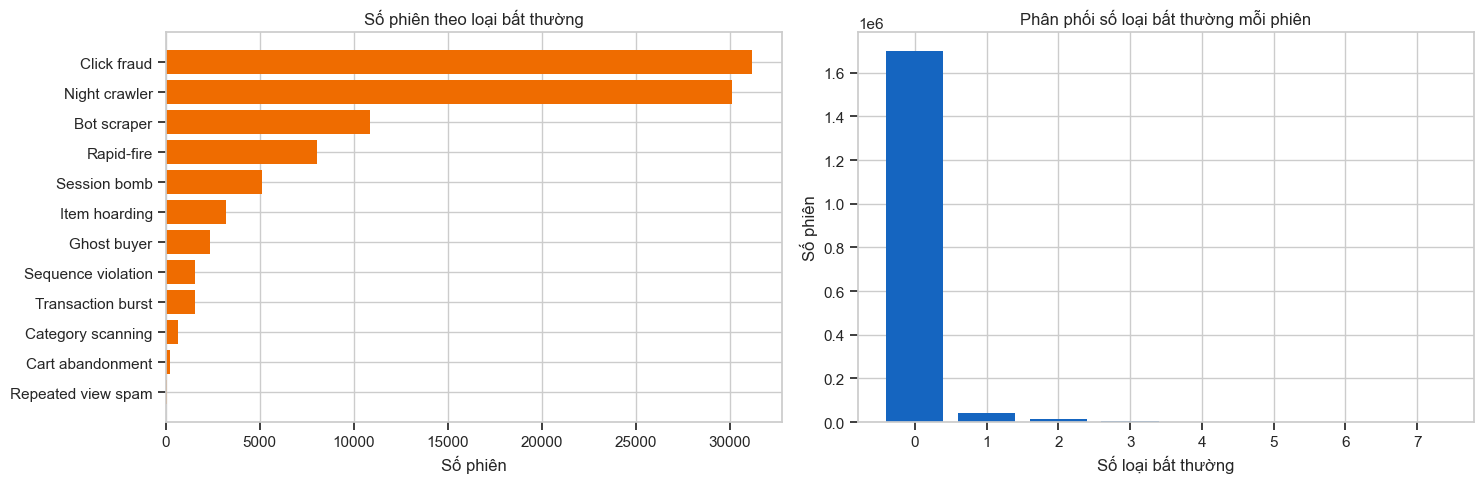

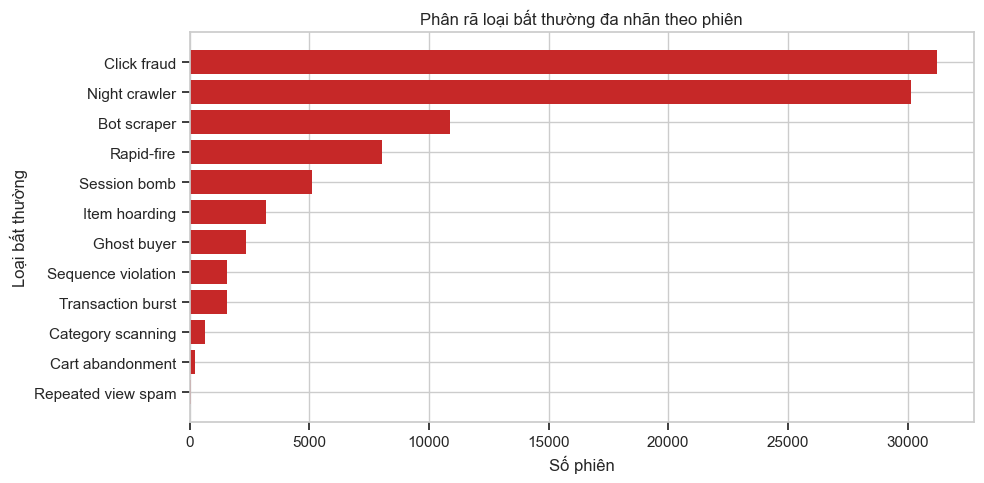

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_rules = rule_summary.sort_values('count', ascending=True)
axes[0].barh(plot_rules['anomaly_type'], plot_rules['count'], color=COLORS['warning'])
axes[0].set_title('Số phiên theo loại bất thường')
axes[0].set_xlabel('Số phiên')

flag_distribution = anomalies['total_flags'].value_counts().sort_index()
axes[1].bar(flag_distribution.index.astype(str), flag_distribution.values, color=COLORS['primary'])
axes[1].set_title('Phân phối số loại bất thường mỗi phiên')
axes[1].set_xlabel('Số loại bất thường')
axes[1].set_ylabel('Số phiên')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_rule_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
plot_type_breakdown = anomaly_type_breakdown.sort_values('count', ascending=True)
ax.barh(plot_type_breakdown['anomaly_type'], plot_type_breakdown['count'], color=COLORS['anomaly'])
ax.set_title('Phân rã loại bất thường đa nhãn theo phiên')
ax.set_xlabel('Số phiên')
ax.set_ylabel('Loại bất thường')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_anomaly_type_breakdown.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Kiểm tra rò rỉ nhãn theo luật nghiệp vụ

`full_feature_cols` chứa các feature tạo luật để minh họa rule-mimic. `safe_feature_cols` loại feature trực tiếp tạo nhãn và dùng cho bảng metric chính.

Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.


,rule,business_condition,rule_input_features,leaked_inputs_in_full_features,inputs_remaining_in_safe_features,n_leaked_inputs
0,BR01_bot_scraper,total_events >= 12 or events_per_minute >= 8 w...,"[total_events, events_per_minute]","[total_events, events_per_minute]",[],2
1,BR02_ghost_buyer,n_transaction > 0 and n_addtocart == 0,"[n_transaction, n_addtocart]","[n_transaction, n_addtocart]",[],2
2,BR03_click_fraud,n_view >= 6 and n_addtocart == 0 and n_transac...,"[n_view, n_addtocart, n_transaction]","[n_view, n_addtocart, n_transaction]",[],3
3,BR04_rapid_fire,rapid_fire_count >= 1 or rapid_ratio >= 0.20 w...,"[rapid_fire_count, rapid_ratio, total_events]","[rapid_fire_count, rapid_ratio, total_events]",[],3
4,BR05_night_crawler,night_ratio >= 0.75 and total_events >= 4,"[night_ratio, night_events, total_events]","[night_ratio, night_events, total_events]",[],3
5,BR06_item_hoarding,max_same_item_atc > 1,[max_same_item_atc],[max_same_item_atc],[],1
6,BR07_session_bomb,unique_items >= 12,[unique_items],[unique_items],[],1
7,BR08_sequence_violation,transaction before prior view/addtocart on sam...,[raw_event_sequence],[],[],0
8,BR09_transaction_burst,n_transaction >= 3,[n_transaction],[n_transaction],[],1
9,BR10_cart_abandonment,n_addtocart >= 10 and n_transaction == 0,"[n_addtocart, n_transaction]","[n_addtocart, n_transaction]",[],2


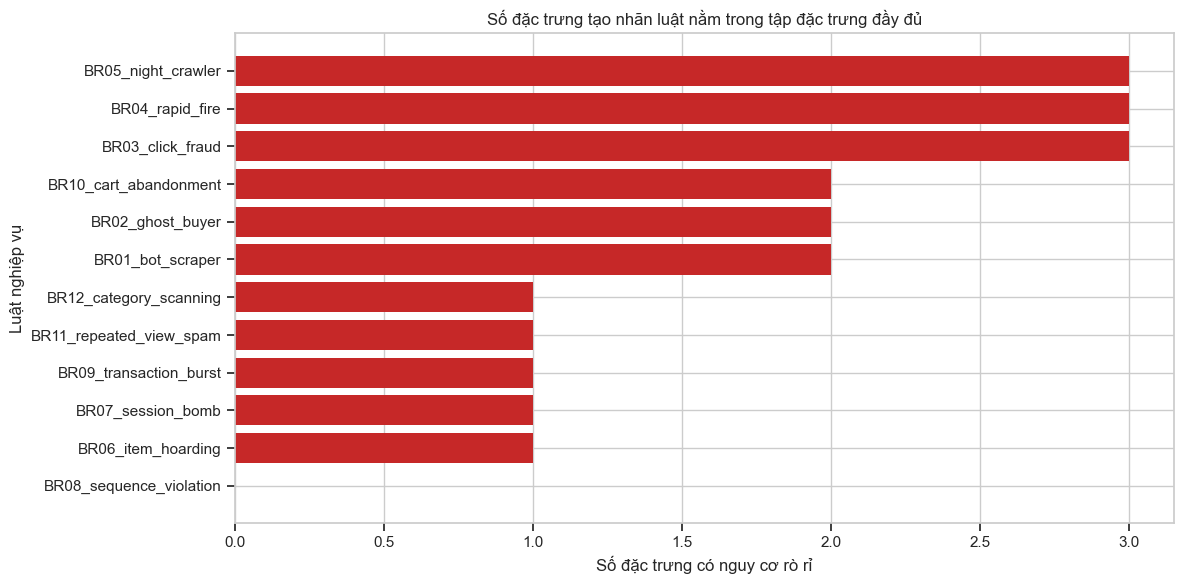

In [8]:
leakage_audit_df = pd.DataFrame([
    {'rule': 'BR01_bot_scraper', 'business_condition': 'total_events >= 12 or events_per_minute >= 8 with enough events', 'rule_input_features': ['total_events', 'events_per_minute']},
    {'rule': 'BR02_ghost_buyer', 'business_condition': 'n_transaction > 0 and n_addtocart == 0', 'rule_input_features': ['n_transaction', 'n_addtocart']},
    {'rule': 'BR03_click_fraud', 'business_condition': 'n_view >= 6 and n_addtocart == 0 and n_transaction == 0', 'rule_input_features': ['n_view', 'n_addtocart', 'n_transaction']},
    {'rule': 'BR04_rapid_fire', 'business_condition': 'rapid_fire_count >= 1 or rapid_ratio >= 0.20 with enough events', 'rule_input_features': ['rapid_fire_count', 'rapid_ratio', 'total_events']},
    {'rule': 'BR05_night_crawler', 'business_condition': 'night_ratio >= 0.75 and total_events >= 4', 'rule_input_features': ['night_ratio', 'night_events', 'total_events']},
    {'rule': 'BR06_item_hoarding', 'business_condition': 'max_same_item_atc > 1', 'rule_input_features': ['max_same_item_atc']},
    {'rule': 'BR07_session_bomb', 'business_condition': 'unique_items >= 12', 'rule_input_features': ['unique_items']},
    {'rule': 'BR08_sequence_violation', 'business_condition': 'transaction before prior view/addtocart on same session-item timeline', 'rule_input_features': ['raw_event_sequence']},
    {'rule': 'BR09_transaction_burst', 'business_condition': 'n_transaction >= 3', 'rule_input_features': ['n_transaction']},
    {'rule': 'BR10_cart_abandonment', 'business_condition': 'n_addtocart >= 10 and n_transaction == 0', 'rule_input_features': ['n_addtocart', 'n_transaction']},
    {'rule': 'BR11_repeated_view_spam', 'business_condition': 'max_same_item_view >= 20', 'rule_input_features': ['max_same_item_view']},
    {'rule': 'BR12_category_scanning', 'business_condition': 'unique_categories >= 20', 'rule_input_features': ['unique_categories']},
])

full_feature_cols = [
    'total_events', 'unique_items', 'session_duration_sec', 'duration_min', 'events_per_minute',
    'n_view', 'n_addtocart', 'n_transaction', 'active_hours', 'unique_event_types',
    'event_type_entropy', 'hour_entropy', 'min_interval_sec', 'mean_interval_sec',
    'median_interval_sec', 'std_interval_sec', 'max_interval_sec', 'rapid_fire_count',
    'night_events', 'peak_events', 'weekend_events', 'view_rate', 'atc_rate', 'buy_rate',
    'night_ratio', 'peak_ratio', 'weekend_ratio', 'rapid_ratio', 'items_per_event',
    'view_to_cart_ratio', 'cart_to_transaction_ratio', 'max_same_item_view', 'max_same_item_atc',
    'unique_categories', 'unique_parent_categories', 'session_start_hour', 'session_dayofweek',
]

safe_feature_cols = [
    'session_duration_sec',
    'active_hours',
    'unique_event_types',
    'event_type_entropy',
    'hour_entropy',
    'mean_interval_sec',
    'median_interval_sec',
    'std_interval_sec',
    'max_interval_sec',
    'peak_events',
    'weekend_events',
    'peak_ratio',
    'weekend_ratio',
    'unique_parent_categories',
    'session_dayofweek',
]

leaky_feature_set = set(full_feature_cols).difference(safe_feature_cols)
leakage_audit_df['leaked_inputs_in_full_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in leaky_feature_set]
)
leakage_audit_df['inputs_remaining_in_safe_features'] = leakage_audit_df['rule_input_features'].apply(
    lambda cols: [col for col in cols if col in safe_feature_cols]
)
leakage_audit_df['n_leaked_inputs'] = leakage_audit_df['leaked_inputs_in_full_features'].str.len()

print('Kiểm tra rò rỉ nhãn: tập đặc trưng an toàn đã loại bỏ các đặc trưng trực tiếp tạo ra luật.')
display(leakage_audit_df)

if leakage_audit_df['inputs_remaining_in_safe_features'].str.len().sum() != 0:
    raise ValueError('safe_feature_cols vẫn chứa đặc trưng trực tiếp tạo nhãn luật')

fig, ax = plt.subplots(figsize=(12, 6))
plot_leakage = leakage_audit_df.sort_values('n_leaked_inputs', ascending=True)
ax.barh(plot_leakage['rule'], plot_leakage['n_leaked_inputs'], color=COLORS['anomaly'])
ax.set_title('Số đặc trưng tạo nhãn luật nằm trong tập đặc trưng đầy đủ')
ax.set_xlabel('Số đặc trưng có nguy cơ rò rỉ')
ax.set_ylabel('Luật nghiệp vụ')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_leakage_audit.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Chuẩn bị dữ liệu mô hình

Bảng metric chính dùng `safe_feature_cols`; bảng phụ `full_feature_cols` chỉ để chứng minh mô hình học lại luật khi có leakage.

Dữ liệu supervised được chia theo tỉ lệ **60% train - 20% validation - 20% test**. Validation dùng để chọn ngưỡng dự đoán/anomaly score, còn test dùng làm kết quả báo cáo cuối.


In [9]:
def make_clean_matrix(source_df, columns):
    X_matrix = source_df[columns].replace([np.inf, -np.inf], np.nan).fillna(0).astype('float32')
    if X_matrix.isna().any().any():
        raise ValueError('X van con NaN sau tien xu ly')
    if not np.isfinite(X_matrix.to_numpy()).all():
        raise ValueError('X van con inf sau tien xu ly')
    return X_matrix

X_full = make_clean_matrix(anomalies, full_feature_cols)
X_safe = make_clean_matrix(anomalies, safe_feature_cols)
y = anomalies['is_anomaly_rule'].astype(int)

if y.nunique() != 2:
    raise ValueError('Nhan is_anomaly_rule phai co du 2 lop')

all_indices = np.arange(len(y))
if MAX_SUPERVISED_ROWS is not None and len(y) > MAX_SUPERVISED_ROWS:
    supervised_indices, _ = train_test_split(
        all_indices,
        train_size=MAX_SUPERVISED_ROWS,
        random_state=RANDOM_STATE,
        stratify=y,
    )
else:
    supervised_indices = all_indices

# Tach du lieu theo NHOM visitorid de tranh ro ri: cac session cua cung
# mot visitor khong duoc xuat hien o ca train va test.
groups_all = anomalies['visitorid'].to_numpy()
groups_sup = groups_all[supervised_indices]
y_sup = y.iloc[supervised_indices].to_numpy()

# Tach test (20%) theo nhom visitor
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
trainval_pos, test_pos = next(gss_test.split(supervised_indices, y_sup, groups_sup))
train_val_idx = supervised_indices[trainval_pos]
test_idx = supervised_indices[test_pos]

# Tach validation (25% cua phan con lai = 20% tong) theo nhom visitor
groups_tv = groups_all[train_val_idx]
y_tv = y.iloc[train_val_idx].to_numpy()
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_pos, val_pos = next(gss_val.split(train_val_idx, y_tv, groups_tv))
train_idx = train_val_idx[train_pos]
val_idx = train_val_idx[val_pos]

X_safe_train = X_safe.iloc[train_idx]
X_safe_val = X_safe.iloc[val_idx]
X_safe_test = X_safe.iloc[test_idx]
X_full_train = X_full.iloc[train_idx]
X_full_val = X_full.iloc[val_idx]
X_full_test = X_full.iloc[test_idx]
y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

safe_scaler = RobustScaler()
safe_scaler.fit(X_safe_train)
X_safe_scaled = safe_scaler.transform(X_safe).astype('float32')
X_safe_scaled_train = X_safe_scaled[train_idx]
X_safe_scaled_val = X_safe_scaled[val_idx]
X_safe_scaled_test = X_safe_scaled[test_idx]

full_scaler = RobustScaler()
full_scaler.fit(X_full_train)
X_full_scaled = full_scaler.transform(X_full).astype('float32')

print(f'Toan bo session profile: {len(X_safe):,} dong')
print(f'Mau supervised training/validation/test: {len(supervised_indices):,} dong')
print(f'Train: {len(train_idx):,}; Validation: {len(val_idx):,}; Test: {len(test_idx):,}')
print(f'Ty le anomaly trong toan bo session: {y.mean() * 100:.2f}%')
print(f'Ty le anomaly trong train: {y_train.mean() * 100:.2f}%')
print(f'Ty le anomaly trong validation: {y_val.mean() * 100:.2f}%')
print(f'Ty le anomaly trong test: {y_test.mean() * 100:.2f}%')
print(f'So safe features: {len(safe_feature_cols)}; So full features: {len(full_feature_cols)}')

# Kiem tra ro ri theo visitor: khong visitorid nao duoc nam o nhieu tap
v_train = set(groups_all[train_idx])
v_val = set(groups_all[val_idx])
v_test = set(groups_all[test_idx])
overlap_tv = v_train & v_val
overlap_tt = v_train & v_test
overlap_vt = v_val & v_test
print(f'Visitor train/val/test: {len(v_train):,} / {len(v_val):,} / {len(v_test):,}')
print(f'Trung visitor train-val: {len(overlap_tv)}; train-test: {len(overlap_tt)}; val-test: {len(overlap_vt)}')
assert not (overlap_tv or overlap_tt or overlap_vt), 'Van con visitor bi ro ri giua cac tap!'
print('OK: khong co visitor nao bi ro ri giua train/validation/test (group split theo visitorid).')


Toan bo session profile: 1,761,675 dong
Mau supervised training/validation/test: 300,000 dong
Train: 179,962; Validation: 59,981; Test: 60,057
Ty le anomaly trong toan bo session: 3.51%
Ty le anomaly trong train: 3.51%
Ty le anomaly trong validation: 3.50%
Ty le anomaly trong test: 3.52%
So safe features: 15; So full features: 37
Visitor train/val/test: 167,040 / 55,680 / 55,680
Trung visitor train-val: 0; train-test: 0; val-test: 0
OK: khong co visitor nao bi ro ri giua train/validation/test (group split theo visitorid).


In [10]:
evaluation_records = []
prediction_sets = {}


def choose_best_threshold(y_true, y_score, label, metric='f1'):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score, dtype='float64')
    if len(y_score) == 0 or len(np.unique(y_score)) <= 1:
        print(f'{label}: score khong du bien thien, dung threshold mac dinh 0.5')
        return 0.5

    candidate_thresholds = np.unique(np.r_[0.5, np.quantile(y_score, np.linspace(0.01, 0.99, 99))])
    best_threshold = 0.5
    best_value = -1.0
    best_precision = -1.0
    best_recall = -1.0

    for threshold in candidate_thresholds:
        y_pred = (y_score >= threshold).astype(int)
        if metric == 'recall':
            value = recall_score(y_true, y_pred, zero_division=0)
        elif metric == 'precision':
            value = precision_score(y_true, y_pred, zero_division=0)
        else:
            value = f1_score(y_true, y_pred, zero_division=0)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if (
            value > best_value
            or (np.isclose(value, best_value) and precision > best_precision)
            or (np.isclose(value, best_value) and np.isclose(precision, best_precision) and recall > best_recall)
        ):
            best_threshold = float(threshold)
            best_value = float(value)
            best_precision = float(precision)
            best_recall = float(recall)

    print(
        f'{label}: chon threshold={best_threshold:.4f} tren validation '
        f'({metric}={best_value:.4f}, precision={best_precision:.4f}, recall={best_recall:.4f})'
    )
    return best_threshold


def add_evaluation(model_name, feature_set, evaluation_type, split, y_true, y_pred, y_score=None, threshold=np.nan, store_confusion=True):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    record = {
        'model': model_name,
        'feature_set': feature_set,
        'evaluation_type': evaluation_type,
        'split': split,
        'threshold': threshold,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1_score': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': np.nan,
        'pr_auc': np.nan,
        'support_anomaly': int(y_true.sum()),
        'predicted_anomaly': int(y_pred.sum()),
    }

    if y_score is not None and len(np.unique(y_true)) == 2:
        try:
            record['roc_auc'] = roc_auc_score(y_true, y_score)
        except ValueError:
            record['roc_auc'] = np.nan
        try:
            record['pr_auc'] = average_precision_score(y_true, y_score)
        except ValueError:
            record['pr_auc'] = np.nan

    evaluation_records.append(record)
    key = f'{model_name} ({feature_set})'
    if store_confusion:
        prediction_sets[key] = {'y_true': y_true, 'y_pred': y_pred, 'evaluation_type': evaluation_type, 'split': split}

    print()
    print(f'{model_name} - {feature_set} - {evaluation_type} - {split}')
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'], zero_division=0))


## 7. Baseline và mô hình supervised trên safe feature set

Các mô hình supervised học trên `train`, chọn threshold bằng `validation`, và chỉ dùng `test` để báo cáo kết quả cuối.


In [11]:
dummy_model = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy_model.fit(X_safe_train, y_train)

dummy_val_pred = dummy_model.predict(X_safe_val)
dummy_val_score = dummy_model.predict_proba(X_safe_val)[:, 1]
add_evaluation(
    'Dummy baseline',
    'safe_features',
    'Baseline so với nhãn giả phiên',
    'validation',
    y_val,
    dummy_val_pred,
    dummy_val_score,
    threshold=0.5,
    store_confusion=False,
)

dummy_test_pred = dummy_model.predict(X_safe_test)
dummy_test_score = dummy_model.predict_proba(X_safe_test)[:, 1]
add_evaluation(
    'Dummy baseline',
    'safe_features',
    'Baseline so với nhãn giả phiên',
    'test',
    y_test,
    dummy_test_pred,
    dummy_test_score,
    threshold=0.5,
    store_confusion=False,
)



Dummy baseline - safe_features - Baseline so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97     57879
     Anomaly       0.05      0.05      0.05      2102

    accuracy                           0.93     59981
   macro avg       0.51      0.51      0.51     59981
weighted avg       0.93      0.93      0.93     59981


Dummy baseline - safe_features - Baseline so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.97     57941
     Anomaly       0.04      0.04      0.04      2116

    accuracy                           0.93     60057
   macro avg       0.50      0.50      0.50     60057
weighted avg       0.93      0.93      0.93     60057



<a id="section-xgboost"></a>

### Đình Tuấn - XGBoost

In [12]:
def make_xgb_model(n_estimators=120, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

xgb_safe_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_safe_model.fit(X_safe_train, y_train)

xgb_safe_val_score = xgb_safe_model.predict_proba(X_safe_val)[:, 1]
xgb_safe_threshold = choose_best_threshold(y_val, xgb_safe_val_score, 'XGBoost safe_features')
xgb_safe_val_pred = (xgb_safe_val_score >= xgb_safe_threshold).astype(int)
add_evaluation(
    'XGBoost',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'validation',
    y_val,
    xgb_safe_val_pred,
    xgb_safe_val_score,
    threshold=xgb_safe_threshold,
    store_confusion=False,
)

xgb_safe_test_score = xgb_safe_model.predict_proba(X_safe_test)[:, 1]
xgb_safe_test_pred = (xgb_safe_test_score >= xgb_safe_threshold).astype(int)
add_evaluation(
    'XGBoost',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'test',
    y_test,
    xgb_safe_test_pred,
    xgb_safe_test_score,
    threshold=xgb_safe_threshold,
)
    
anomalies['xgboost_score'] = xgb_safe_model.predict_proba(X_safe)[:, 1]
anomalies['xgboost_pred'] = (anomalies['xgboost_score'] >= xgb_safe_threshold).astype(int)


XGBoost safe_features: chon threshold=0.8693 tren validation (f1=0.8676, precision=0.8137, recall=0.9291)

XGBoost - safe_features - Main supervised so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     57879
     Anomaly       0.81      0.93      0.87      2102

    accuracy                           0.99     59981
   macro avg       0.91      0.96      0.93     59981
weighted avg       0.99      0.99      0.99     59981


XGBoost - safe_features - Main supervised so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     57941
     Anomaly       0.81      0.92      0.86      2116

    accuracy                           0.99     60057
   macro avg       0.90      0.96      0.93     60057
weighted avg       0.99      0.99      0.99     60057



### Lê Văn Anh - Decision Tree

Decision Tree safe_features: chon threshold=0.9484 tren validation (f1=0.7494, precision=0.7029, recall=0.8026)

Decision Tree - safe_features - Main supervised so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     57879
     Anomaly       0.70      0.80      0.75      2102

    accuracy                           0.98     59981
   macro avg       0.85      0.90      0.87     59981
weighted avg       0.98      0.98      0.98     59981


Decision Tree - safe_features - Main supervised so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     57941
     Anomaly       0.68      0.78      0.73      2116

    accuracy                           0.98     60057
   macro avg       0.84      0.88      0.86     60057
weighted avg       0.98      0.98      0.98     60057



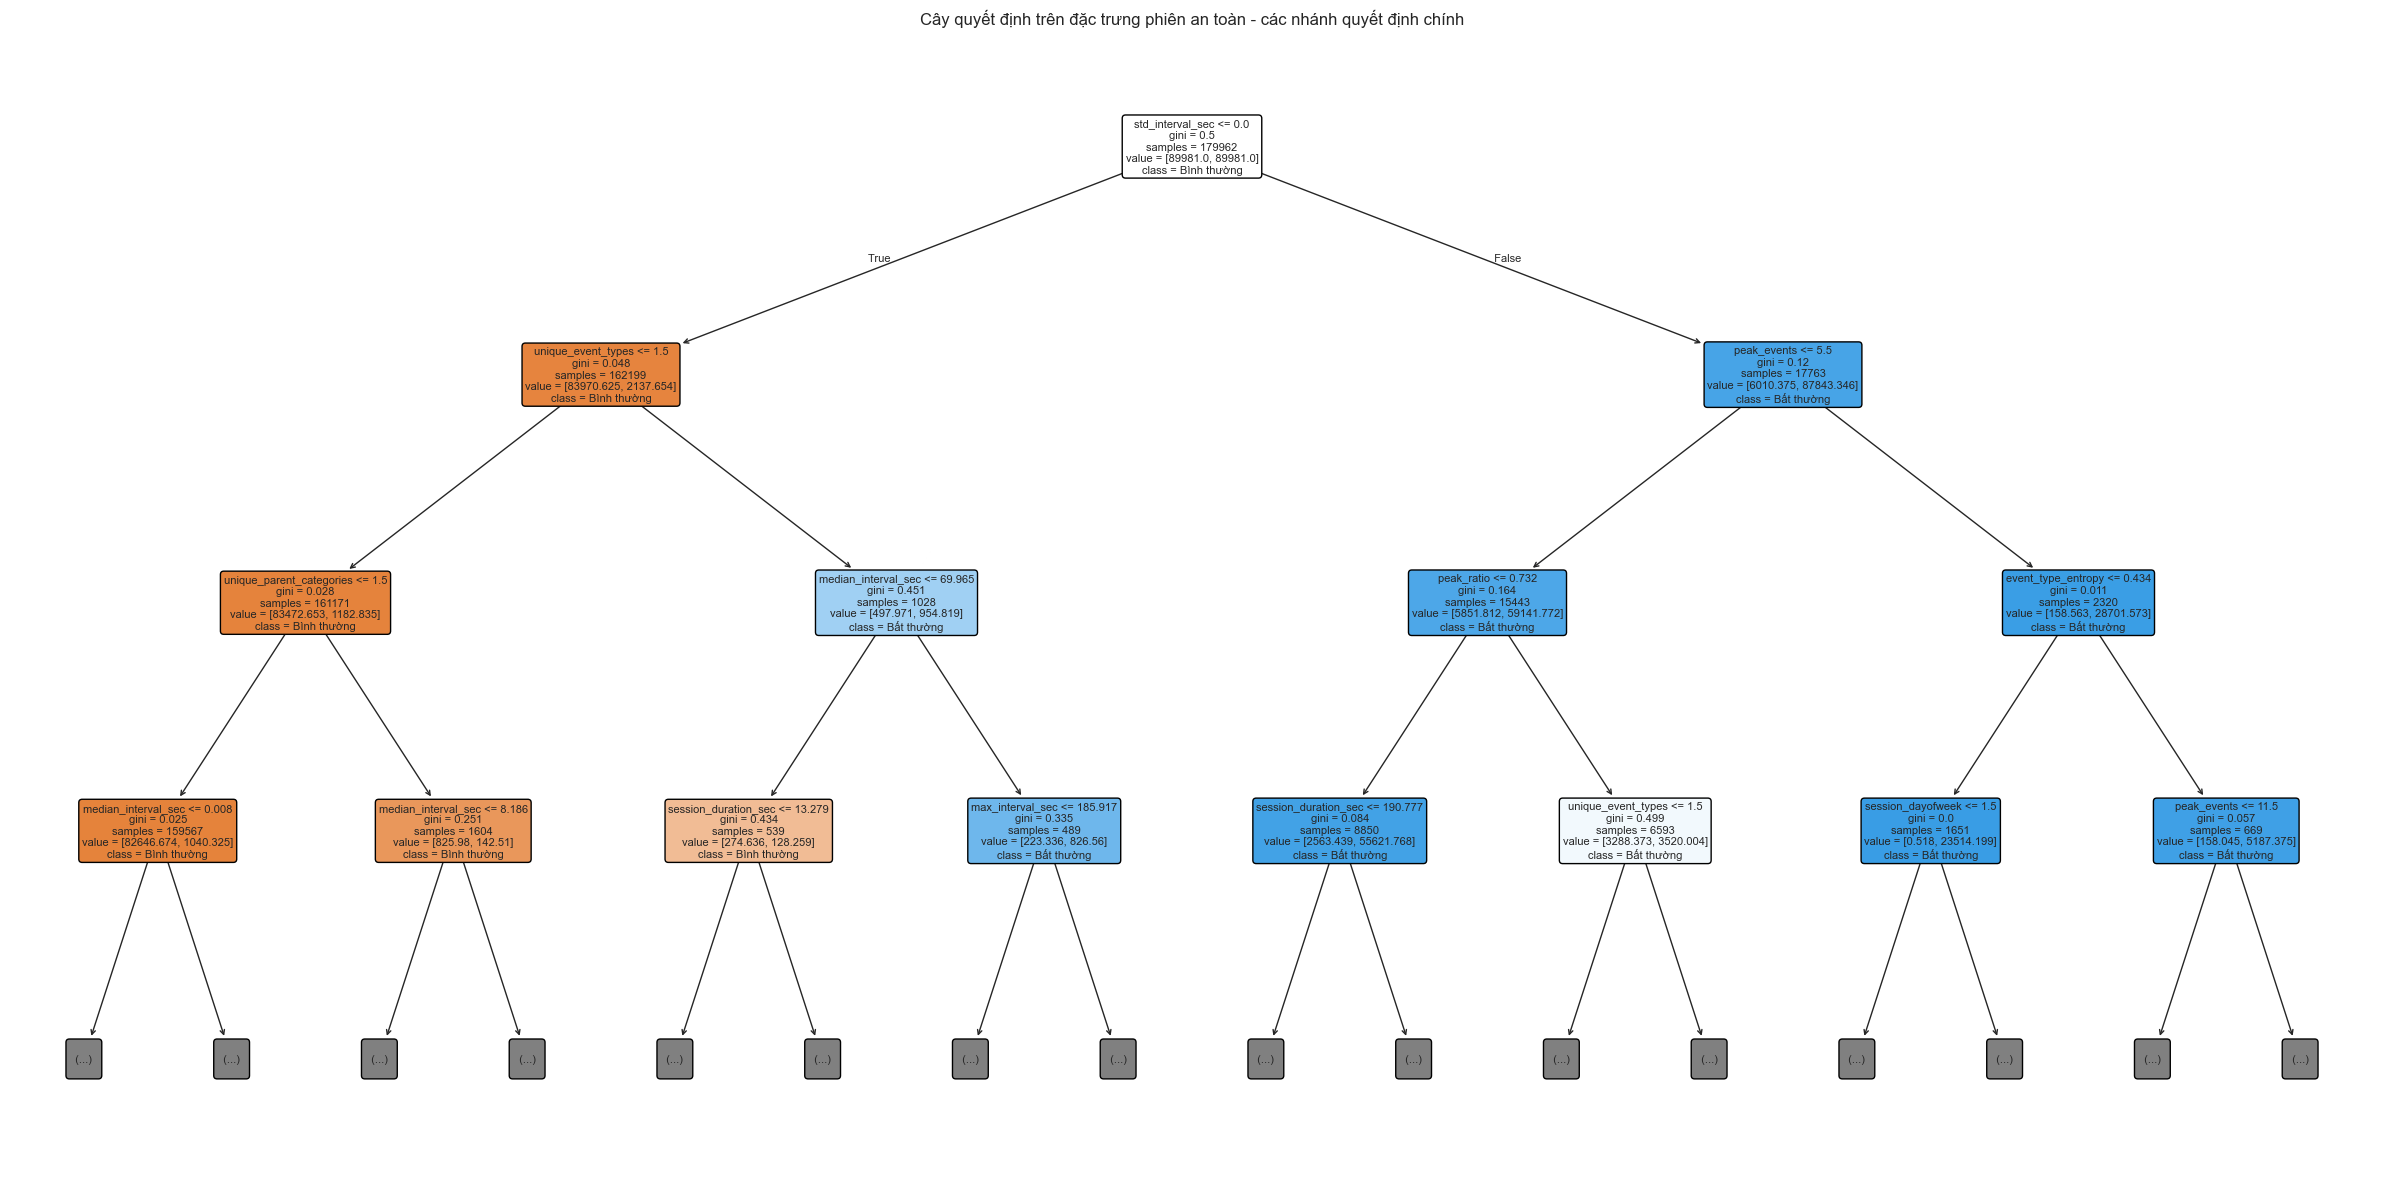

In [13]:
dt_safe_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

dt_safe_model.fit(X_safe_train, y_train)

dt_safe_val_score = dt_safe_model.predict_proba(X_safe_val)[:, 1]
dt_safe_threshold = choose_best_threshold(y_val, dt_safe_val_score, 'Decision Tree safe_features')
dt_safe_val_pred = (dt_safe_val_score >= dt_safe_threshold).astype(int)
add_evaluation(
    'Decision Tree',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'validation',
    y_val,
    dt_safe_val_pred,
    dt_safe_val_score,
    threshold=dt_safe_threshold,
    store_confusion=False,
)

dt_safe_test_score = dt_safe_model.predict_proba(X_safe_test)[:, 1]
dt_safe_test_pred = (dt_safe_test_score >= dt_safe_threshold).astype(int)
add_evaluation(
    'Decision Tree',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'test',
    y_test,
    dt_safe_test_pred,
    dt_safe_test_score,
    threshold=dt_safe_threshold,
)

anomalies['decision_tree_score'] = dt_safe_model.predict_proba(X_safe)[:, 1]
anomalies['decision_tree_pred'] = (anomalies['decision_tree_score'] >= dt_safe_threshold).astype(int)

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(
    dt_safe_model,
    feature_names=safe_feature_cols,
    class_names=['Bình thường', 'Bất thường'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
    ax=ax,
)
ax.set_title('Cây quyết định trên đặc trưng phiên an toàn - các nhánh quyết định chính')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_decision_tree.png', dpi=160, bbox_inches='tight')
plt.show()


<a id="section-random-forest"></a>

### Tuấn Anh - Random Forest

In [14]:
rf_safe_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=10,
    min_samples_leaf=50,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_safe_model.fit(X_safe_train, y_train)

rf_safe_val_score = rf_safe_model.predict_proba(X_safe_val)[:, 1]
rf_safe_threshold = choose_best_threshold(y_val, rf_safe_val_score, 'Random Forest safe_features')
rf_safe_val_pred = (rf_safe_val_score >= rf_safe_threshold).astype(int)
add_evaluation(
    'Random Forest',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'validation',
    y_val,
    rf_safe_val_pred,
    rf_safe_val_score,
    threshold=rf_safe_threshold,
    store_confusion=False,
)

rf_safe_test_score = rf_safe_model.predict_proba(X_safe_test)[:, 1]
rf_safe_test_pred = (rf_safe_test_score >= rf_safe_threshold).astype(int)
add_evaluation(
    'Random Forest',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'test',
    y_test,
    rf_safe_test_pred,
    rf_safe_test_score,
    threshold=rf_safe_threshold,
)

anomalies['random_forest_score'] = rf_safe_model.predict_proba(X_safe)[:, 1]
anomalies['random_forest_pred'] = (anomalies['random_forest_score'] >= rf_safe_threshold).astype(int)


Random Forest safe_features: chon threshold=0.8477 tren validation (f1=0.8583, precision=0.8050, recall=0.9191)

Random Forest - safe_features - Main supervised so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     57879
     Anomaly       0.81      0.92      0.86      2102

    accuracy                           0.99     59981
   macro avg       0.90      0.96      0.93     59981
weighted avg       0.99      0.99      0.99     59981


Random Forest - safe_features - Main supervised so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     57941
     Anomaly       0.80      0.91      0.85      2116

    accuracy                           0.99     60057
   macro avg       0.90      0.95      0.92     60057
weighted avg       0.99      0.99      0.99     60057



### Thủy - LightGBM


In [15]:
def make_lgbm_model(n_estimators=160, scale_pos_weight=1.0):
    return LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=80,
        subsample=0.85,
        colsample_bytree=0.85,
        objective='binary',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        reg_lambda=1.0,
        verbosity=-1,
        force_col_wise=True,
    )

lgbm_safe_model = make_lgbm_model(n_estimators=160, scale_pos_weight=scale_pos_weight)
lgbm_safe_model.fit(X_safe_train, y_train)

lgbm_safe_val_score = lgbm_safe_model.predict_proba(X_safe_val)[:, 1]
lgbm_safe_threshold = choose_best_threshold(y_val, lgbm_safe_val_score, 'LightGBM safe_features')
lgbm_safe_val_pred = (lgbm_safe_val_score >= lgbm_safe_threshold).astype(int)
add_evaluation(
    'LightGBM',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'validation',
    y_val,
    lgbm_safe_val_pred,
    lgbm_safe_val_score,
    threshold=lgbm_safe_threshold,
    store_confusion=False,
)

lgbm_safe_test_score = lgbm_safe_model.predict_proba(X_safe_test)[:, 1]
lgbm_safe_test_pred = (lgbm_safe_test_score >= lgbm_safe_threshold).astype(int)
add_evaluation(
    'LightGBM',
    'safe_features',
    'Main supervised so với nhãn giả phiên',
    'test',
    y_test,
    lgbm_safe_test_pred,
    lgbm_safe_test_score,
    threshold=lgbm_safe_threshold,
)

anomalies['lightgbm_score'] = lgbm_safe_model.predict_proba(X_safe)[:, 1]
anomalies['lightgbm_pred'] = (anomalies['lightgbm_score'] >= lgbm_safe_threshold).astype(int)


LightGBM safe_features: chon threshold=0.8664 tren validation (f1=0.8796, precision=0.8250, recall=0.9420)

LightGBM - safe_features - Main supervised so với nhãn giả phiên - validation
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     57879
     Anomaly       0.82      0.94      0.88      2102

    accuracy                           0.99     59981
   macro avg       0.91      0.97      0.94     59981
weighted avg       0.99      0.99      0.99     59981


LightGBM - safe_features - Main supervised so với nhãn giả phiên - test
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     57941
     Anomaly       0.82      0.93      0.87      2116

    accuracy                           0.99     60057
   macro avg       0.91      0.96      0.93     60057
weighted avg       0.99      0.99      0.99     60057



## 8. Bảng phụ: mô hình học lại luật bằng full feature set

Phần này cố tình giữ các feature tạo luật để chứng minh vì sao metric có thể quá đẹp khi bị leakage. Validation vẫn được dùng để chọn threshold, còn test dùng để kiểm tra mức độ rule-mimic cuối cùng.


In [16]:
xgb_full_model = make_xgb_model(n_estimators=120, scale_pos_weight=scale_pos_weight)
xgb_full_model.fit(X_full_train, y_train)
xgb_full_val_score = xgb_full_model.predict_proba(X_full_val)[:, 1]
xgb_full_threshold = choose_best_threshold(y_val, xgb_full_val_score, 'XGBoost full_features')
xgb_full_val_pred = (xgb_full_val_score >= xgb_full_threshold).astype(int)
add_evaluation('XGBoost', 'full_features', 'Rule-mimic / agreement with session business rules', 'validation', y_val, xgb_full_val_pred, xgb_full_val_score, threshold=xgb_full_threshold, store_confusion=False)
xgb_full_test_score = xgb_full_model.predict_proba(X_full_test)[:, 1]
xgb_full_test_pred = (xgb_full_test_score >= xgb_full_threshold).astype(int)
add_evaluation('XGBoost', 'full_features', 'Rule-mimic / agreement with session business rules', 'test', y_test, xgb_full_test_pred, xgb_full_test_score, threshold=xgb_full_threshold, store_confusion=False)

lgbm_full_model = make_lgbm_model(n_estimators=160, scale_pos_weight=scale_pos_weight)
lgbm_full_model.fit(X_full_train, y_train)
lgbm_full_val_score = lgbm_full_model.predict_proba(X_full_val)[:, 1]
lgbm_full_threshold = choose_best_threshold(y_val, lgbm_full_val_score, 'LightGBM full_features')
lgbm_full_val_pred = (lgbm_full_val_score >= lgbm_full_threshold).astype(int)
add_evaluation('LightGBM', 'full_features', 'Rule-mimic / agreement with session business rules', 'validation', y_val, lgbm_full_val_pred, lgbm_full_val_score, threshold=lgbm_full_threshold, store_confusion=False)
lgbm_full_test_score = lgbm_full_model.predict_proba(X_full_test)[:, 1]
lgbm_full_test_pred = (lgbm_full_test_score >= lgbm_full_threshold).astype(int)
add_evaluation('LightGBM', 'full_features', 'Rule-mimic / agreement with session business rules', 'test', y_test, lgbm_full_test_pred, lgbm_full_test_score, threshold=lgbm_full_threshold, store_confusion=False)

dt_full_model = DecisionTreeClassifier(max_depth=5, min_samples_leaf=100, class_weight='balanced', random_state=RANDOM_STATE)
dt_full_model.fit(X_full_train, y_train)
dt_full_val_score = dt_full_model.predict_proba(X_full_val)[:, 1]
dt_full_threshold = choose_best_threshold(y_val, dt_full_val_score, 'Decision Tree full_features')
dt_full_val_pred = (dt_full_val_score >= dt_full_threshold).astype(int)
add_evaluation('Decision Tree', 'full_features', 'Rule-mimic / agreement with session business rules', 'validation', y_val, dt_full_val_pred, dt_full_val_score, threshold=dt_full_threshold, store_confusion=False)
dt_full_test_score = dt_full_model.predict_proba(X_full_test)[:, 1]
dt_full_test_pred = (dt_full_test_score >= dt_full_threshold).astype(int)
add_evaluation('Decision Tree', 'full_features', 'Rule-mimic / agreement with session business rules', 'test', y_test, dt_full_test_pred, dt_full_test_score, threshold=dt_full_threshold, store_confusion=False)

rf_full_model = RandomForestClassifier(n_estimators=120, max_depth=10, min_samples_leaf=50, class_weight='balanced_subsample', random_state=RANDOM_STATE, n_jobs=-1)
rf_full_model.fit(X_full_train, y_train)
rf_full_val_score = rf_full_model.predict_proba(X_full_val)[:, 1]
rf_full_threshold = choose_best_threshold(y_val, rf_full_val_score, 'Random Forest full_features')
rf_full_val_pred = (rf_full_val_score >= rf_full_threshold).astype(int)
add_evaluation('Random Forest', 'full_features', 'Rule-mimic / agreement with session business rules', 'validation', y_val, rf_full_val_pred, rf_full_val_score, threshold=rf_full_threshold, store_confusion=False)
rf_full_test_score = rf_full_model.predict_proba(X_full_test)[:, 1]
rf_full_test_pred = (rf_full_test_score >= rf_full_threshold).astype(int)
add_evaluation('Random Forest', 'full_features', 'Rule-mimic / agreement with session business rules', 'test', y_test, rf_full_test_pred, rf_full_test_score, threshold=rf_full_threshold, store_confusion=False)


XGBoost full_features: chon threshold=0.5000 tren validation (f1=0.9936, precision=0.9887, recall=0.9986)

XGBoost - full_features - Rule-mimic / agreement with session business rules - validation
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     57879
     Anomaly       0.99      1.00      0.99      2102

    accuracy                           1.00     59981
   macro avg       0.99      1.00      1.00     59981
weighted avg       1.00      1.00      1.00     59981


XGBoost - full_features - Rule-mimic / agreement with session business rules - test
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     57941
     Anomaly       0.99      1.00      0.99      2116

    accuracy                           1.00     60057
   macro avg       0.99      1.00      1.00     60057
weighted avg       1.00      1.00      1.00     60057

LightGBM full_features: chon threshold=0.5000 tren validation (f

## 9. Shuffle-label sanity check

Sanity check vẫn dùng train bị tráo nhãn. Validation chỉ dùng để chọn threshold, sau đó test phải cho kết quả thấp nếu pipeline không còn lỗi nghiêm trọng.


In [17]:
rng = np.random.default_rng(RANDOM_STATE)
y_train_shuffled = pd.Series(rng.permutation(y_train.to_numpy()), index=y_train.index)
shuffle_pos = int((y_train_shuffled == 1).sum())
shuffle_neg = int((y_train_shuffled == 0).sum())
shuffle_scale_pos_weight = shuffle_neg / max(shuffle_pos, 1)

xgb_shuffle_model = make_xgb_model(n_estimators=60, scale_pos_weight=shuffle_scale_pos_weight)
xgb_shuffle_model.fit(X_safe_train, y_train_shuffled)
shuffle_val_score = xgb_shuffle_model.predict_proba(X_safe_val)[:, 1]
shuffle_threshold = choose_best_threshold(y_val, shuffle_val_score, 'XGBoost shuffled-label sanity check')
shuffle_val_pred = (shuffle_val_score >= shuffle_threshold).astype(int)
add_evaluation('XGBoost shuffled-label sanity check', 'safe_features', 'Sanity check: shuffled labels should fail', 'validation', y_val, shuffle_val_pred, shuffle_val_score, threshold=shuffle_threshold, store_confusion=False)

shuffle_test_score = xgb_shuffle_model.predict_proba(X_safe_test)[:, 1]
shuffle_test_pred = (shuffle_test_score >= shuffle_threshold).astype(int)
add_evaluation('XGBoost shuffled-label sanity check', 'safe_features', 'Sanity check: shuffled labels should fail', 'test', y_test, shuffle_test_pred, shuffle_test_score, threshold=shuffle_threshold, store_confusion=False)

shuffle_pr_auc = average_precision_score(y_test, shuffle_test_score)
print(f'PR-AUC shuffled-label test: {shuffle_pr_auc:.4f}; prevalence anomaly test: {y_test.mean():.4f}')
if shuffle_pr_auc > max(0.20, y_test.mean() * 10):
    print('Canh bao: shuffle-label PR-AUC cao bat thuong, can audit lai pipeline.')
else:
    print('Sanity check dat: model khong con dep khi nhan bi trao ngau nhien.')


XGBoost shuffled-label sanity check: chon threshold=0.5133 tren validation (f1=0.2016, precision=0.1891, recall=0.2160)

XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail - validation
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97     57879
     Anomaly       0.19      0.22      0.20      2102

    accuracy                           0.94     59981
   macro avg       0.58      0.59      0.59     59981
weighted avg       0.94      0.94      0.94     59981


XGBoost shuffled-label sanity check - safe_features - Sanity check: shuffled labels should fail - test
              precision    recall  f1-score   support

      Normal       0.97      0.97      0.97     57941
     Anomaly       0.19      0.23      0.21      2116

    accuracy                           0.94     60057
   macro avg       0.58      0.60      0.59     60057
weighted avg       0.94      0.94      0.94     60057

PR-AUC shuff

## 10. Feature importance trên safe session feature set

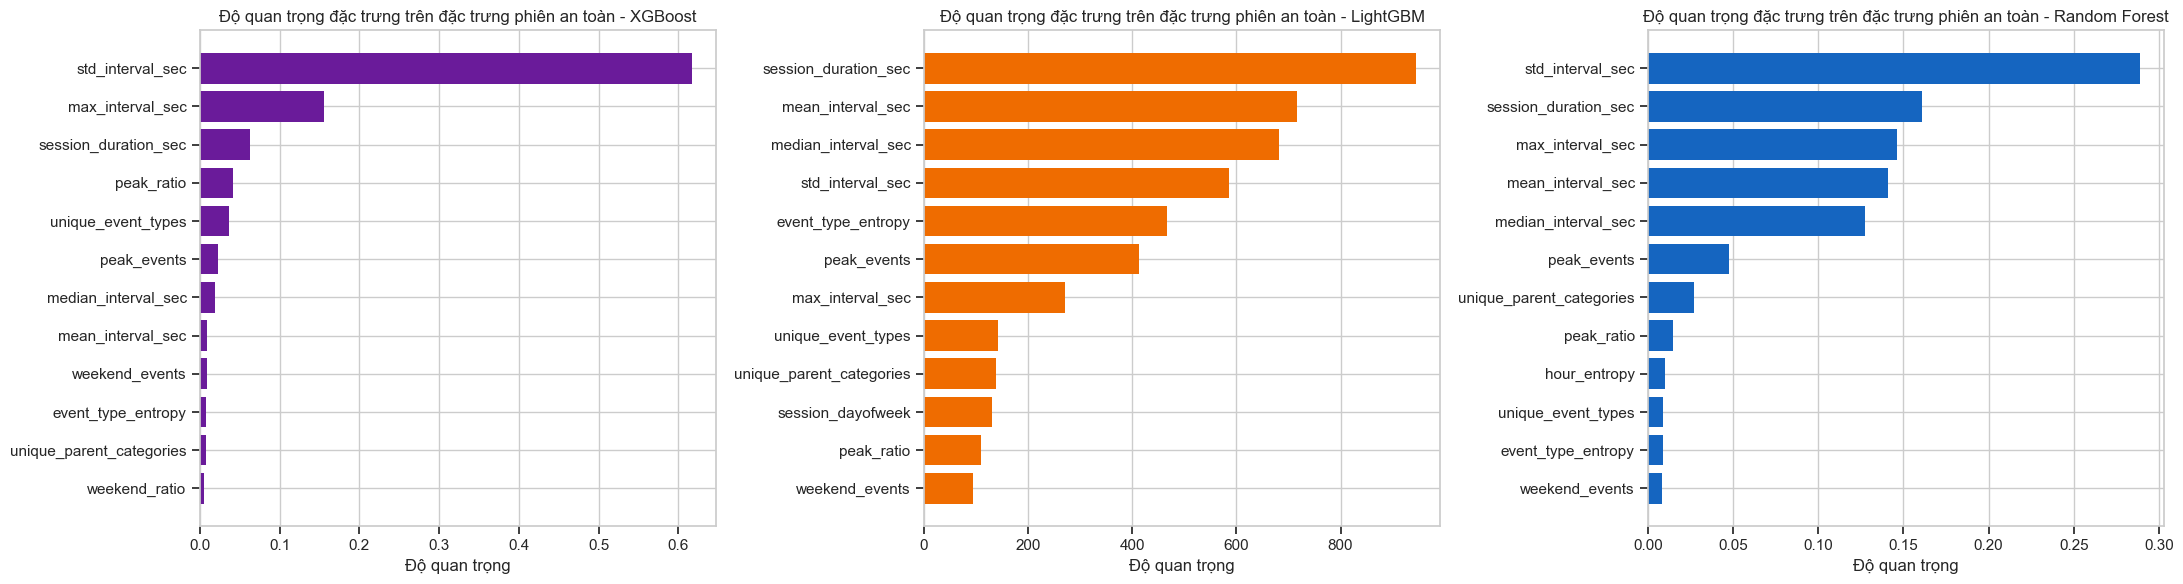

,feature,importance,model
0,std_interval_sec,0.616363,XGBoost
1,max_interval_sec,0.155603,XGBoost
2,session_duration_sec,0.063224,XGBoost
3,peak_ratio,0.041930,XGBoost
4,unique_event_types,0.036756,XGBoost
5,peak_events,0.022541,XGBoost
6,median_interval_sec,0.019217,XGBoost
7,mean_interval_sec,0.009149,XGBoost
8,weekend_events,0.008946,XGBoost
9,event_type_entropy,0.007385,XGBoost


In [18]:
def top_importance_frame(model, feature_names, name, top_n=12):
    frame = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_, 'model': name})
    return frame.sort_values('importance', ascending=False).head(top_n)

importance_models = [
    ('XGBoost', xgb_safe_model, COLORS['secondary']),
    ('LightGBM', lgbm_safe_model, COLORS['warning']),
    ('Random Forest', rf_safe_model, COLORS['primary']),
]
importance_df = pd.concat(
    [top_importance_frame(model, safe_feature_cols, name) for name, model, _ in importance_models],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (model_name, _, color) in zip(axes, importance_models):
    subset = importance_df[importance_df['model'] == model_name].sort_values('importance', ascending=True)
    ax.barh(subset['feature'], subset['importance'], color=color)
    ax.set_title(f'Độ quan trọng đặc trưng trên đặc trưng phiên an toàn - {model_name}')
    ax.set_xlabel('Độ quan trọng')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_feature_importance.png', dpi=160, bbox_inches='tight')
plt.show()

display(importance_df)


<a id="section-isolation-forest"></a>

## 11. Đức Anh - Isolation Forest

Isolation Forest fit trên train không cần nhãn. Validation dùng để chọn ngưỡng anomaly score, sau đó test dùng để báo cáo overlap với pseudo-label.


Isolation Forest score threshold: chon threshold=0.5524 tren validation (f1=0.3988, precision=0.2867, recall=0.6546)

Isolation Forest - safe_features - Unsupervised overlap with session pseudo-label - validation
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96     57879
     Anomaly       0.29      0.65      0.40      2102

    accuracy                           0.93     59981
   macro avg       0.64      0.80      0.68     59981
weighted avg       0.96      0.93      0.94     59981


Isolation Forest - safe_features - Unsupervised overlap with session pseudo-label - test
              precision    recall  f1-score   support

      Normal       0.99      0.94      0.96     57941
     Anomaly       0.29      0.67      0.41      2116

    accuracy                           0.93     60057
   macro avg       0.64      0.81      0.68     60057
weighted avg       0.96      0.93      0.94     60057



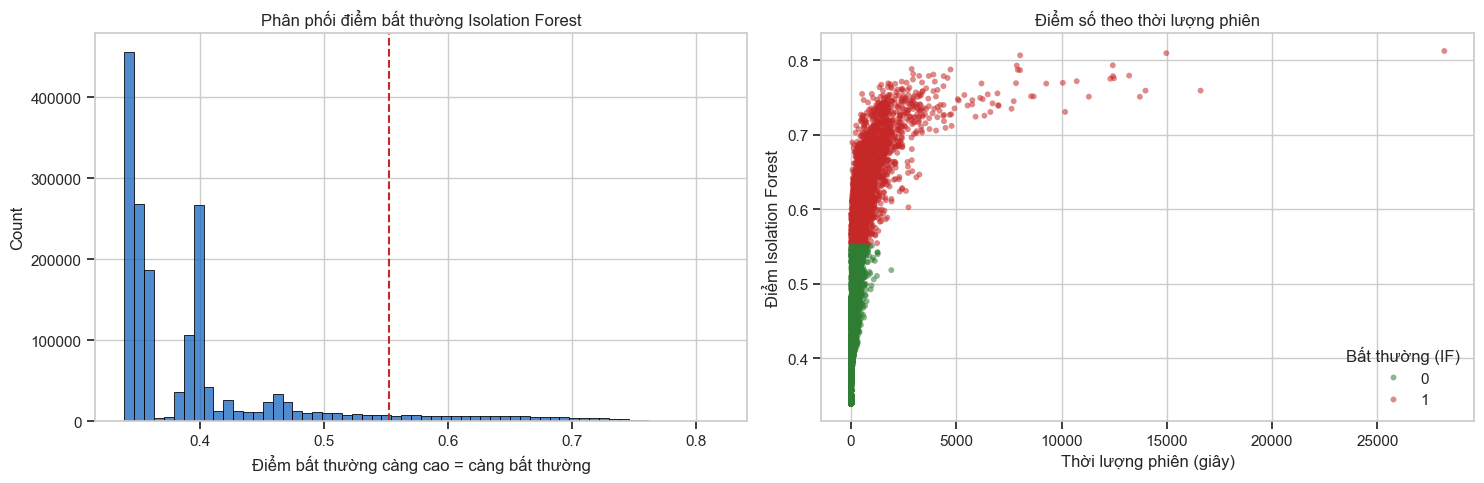

In [19]:
if IFOREST_TRAIN_ROWS is not None and len(train_idx) > IFOREST_TRAIN_ROWS:
    rng = np.random.default_rng(RANDOM_STATE)
    iforest_train_indices = rng.choice(train_idx, size=IFOREST_TRAIN_ROWS, replace=False)
else:
    iforest_train_indices = train_idx

iforest_model = IsolationForest(n_estimators=150, contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
iforest_model.fit(X_safe_scaled[iforest_train_indices])

iforest_score = -iforest_model.score_samples(X_safe_scaled)
iforest_threshold = choose_best_threshold(y_val, iforest_score[val_idx], 'Isolation Forest score threshold')
iforest_pred = (iforest_score >= iforest_threshold).astype(int)

anomalies['isolation_forest_score'] = iforest_score
anomalies['isolation_forest_pred'] = iforest_pred

add_evaluation(
    'Isolation Forest',
    'safe_features',
    'Unsupervised overlap with session pseudo-label',
    'validation',
    y_val,
    iforest_pred[val_idx],
    iforest_score[val_idx],
    threshold=iforest_threshold,
    store_confusion=False,
)
add_evaluation(
    'Isolation Forest',
    'safe_features',
    'Unsupervised overlap with session pseudo-label',
    'test',
    y_test,
    iforest_pred[test_idx],
    iforest_score[test_idx],
    threshold=iforest_threshold,
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(anomalies['isolation_forest_score'], bins=60, color=COLORS['primary'], ax=axes[0])
axes[0].axvline(iforest_threshold, color=COLORS['anomaly'], linestyle='--')
axes[0].set_title('Phân phối điểm bất thường Isolation Forest')
axes[0].set_xlabel('Điểm bất thường càng cao = càng bất thường')

score_sample = anomalies.sample(min(PLOT_SAMPLE_ROWS, len(anomalies)), random_state=RANDOM_STATE)
sns.scatterplot(data=score_sample, x='session_duration_sec', y='isolation_forest_score', hue='isolation_forest_pred', palette={0: COLORS['normal'], 1: COLORS['anomaly']}, alpha=0.55, linewidth=0, s=18, ax=axes[1])
axes[1].set_title('Điểm số theo thời lượng phiên')
axes[1].set_xlabel('Thời lượng phiên (giây)')
axes[1].set_ylabel('Điểm Isolation Forest')
axes[1].legend(title='Bất thường (IF)')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_isolation_scores.png', dpi=160, bbox_inches='tight')
plt.show()


## 13. So sánh 6 thuật toán

Bảng chính dùng `safe_features`. Với supervised models, metric là mức độ khớp với session pseudo-label sau khi giảm leakage. Với unsupervised models, metric là overlap tham khảo với session pseudo-label.

Kết quả được tách thành `validation` và `test`: validation dùng để chọn threshold, test là kết quả báo cáo cuối.


Bảng chỉ số chính trên đặc trưng phiên an toàn / so khớp nhãn giả:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
5,Decision Tree,safe_features,Main supervised so với nhãn giả phiên,test,0.9484,0.9795,0.6842,0.7750,0.7268,0.9871,0.7470,2116,2397
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9327,0.0406,0.0402,0.0404,0.5027,0.0354,2116,2095
21,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,test,0.5524,0.9305,0.2907,0.6744,0.4063,0.9351,0.3578,2116,4909
9,LightGBM,safe_features,Main supervised so với nhãn giả phiên,test,0.8664,0.9904,0.8196,0.9338,0.8730,0.9944,0.9345,2116,2411
7,Random Forest,safe_features,Main supervised so với nhãn giả phiên,test,0.8477,0.9888,0.7989,0.9107,0.8511,0.9922,0.9019,2116,2412
3,XGBoost,safe_features,Main supervised so với nhãn giả phiên,test,0.8693,0.9896,0.8119,0.9178,0.8616,0.9927,0.9220,2116,2392
4,Decision Tree,safe_features,Main supervised so với nhãn giả phiên,validation,0.9484,0.9812,0.7029,0.8026,0.7494,0.9884,0.7663,2102,2400
0,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,validation,0.5000,0.9333,0.0455,0.0452,0.0454,0.5054,0.0355,2102,2087
20,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,validation,0.5524,0.9308,0.2867,0.6546,0.3988,0.9359,0.3399,2102,4799
8,LightGBM,safe_features,Main supervised so với nhãn giả phiên,validation,0.8664,0.9910,0.8250,0.9420,0.8796,0.9953,0.9418,2102,2400


Bảng chỉ số test dùng để báo cáo cuối:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9327,0.0406,0.0402,0.0404,0.5027,0.0354,2116,2095
3,XGBoost,safe_features,Main supervised so với nhãn giả phiên,test,0.8693,0.9896,0.8119,0.9178,0.8616,0.9927,0.9220,2116,2392
5,Decision Tree,safe_features,Main supervised so với nhãn giả phiên,test,0.9484,0.9795,0.6842,0.7750,0.7268,0.9871,0.7470,2116,2397
7,Random Forest,safe_features,Main supervised so với nhãn giả phiên,test,0.8477,0.9888,0.7989,0.9107,0.8511,0.9922,0.9019,2116,2412
9,LightGBM,safe_features,Main supervised so với nhãn giả phiên,test,0.8664,0.9904,0.8196,0.9338,0.8730,0.9944,0.9345,2116,2411
21,Isolation Forest,safe_features,Unsupervised overlap with session pseudo-label,test,0.5524,0.9305,0.2907,0.6744,0.4063,0.9351,0.3578,2116,4909


Bảng phụ: đặc trưng đầy đủ học lại luật phiên:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
15,Decision Tree,full_features,Rule-mimic / agreement with session business r...,test,1.0000,0.9978,1.0000,0.9386,0.9683,0.9997,0.9963,2116,1986
13,LightGBM,full_features,Rule-mimic / agreement with session business r...,test,0.5000,0.9999,0.9981,0.9991,0.9986,1.0000,0.9999,2116,2118
17,Random Forest,full_features,Rule-mimic / agreement with session business r...,test,0.5158,0.9943,0.8615,0.9995,0.9254,0.9999,0.9960,2116,2455
11,XGBoost,full_features,Rule-mimic / agreement with session business r...,test,0.5000,0.9996,0.9892,0.9995,0.9944,1.0000,0.9999,2116,2138
14,Decision Tree,full_features,Rule-mimic / agreement with session business r...,validation,1.0000,0.9981,1.0000,0.9472,0.9729,0.9992,0.9958,2102,1991
12,LightGBM,full_features,Rule-mimic / agreement with session business r...,validation,0.5000,0.9998,0.9976,0.9981,0.9979,1.0000,0.9999,2102,2103
16,Random Forest,full_features,Rule-mimic / agreement with session business r...,validation,0.5158,0.9949,0.8743,0.9990,0.9325,0.9999,0.9973,2102,2402
10,XGBoost,full_features,Rule-mimic / agreement with session business r...,validation,0.5000,0.9995,0.9887,0.9986,0.9936,1.0000,0.9998,2102,2123


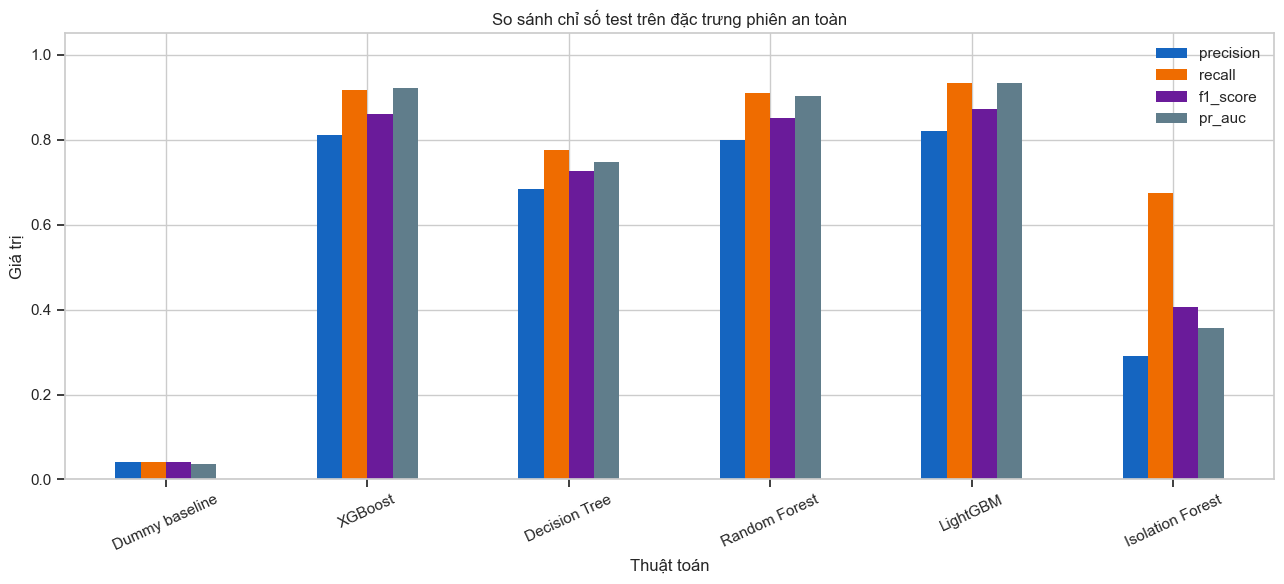

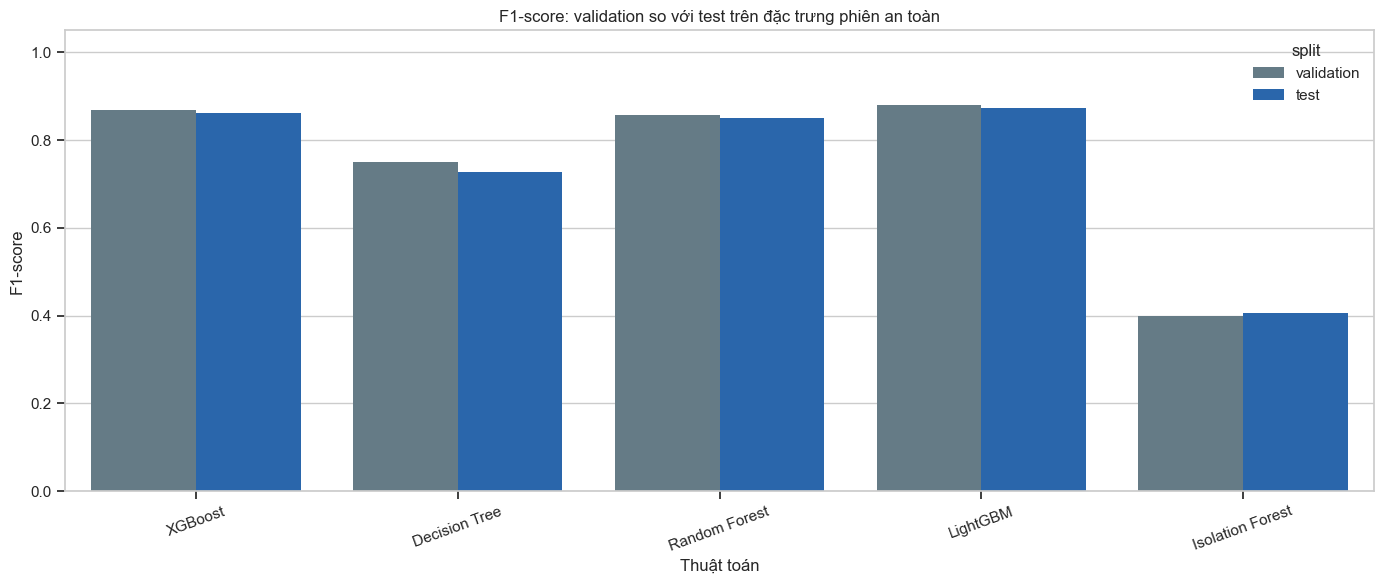

In [20]:
metrics_df = pd.DataFrame(evaluation_records)
metric_cols = ['threshold', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'pr_auc']
metrics_df[metric_cols] = metrics_df[metric_cols].round(4)

main_metrics_df = metrics_df[
    metrics_df['evaluation_type'].isin([
        'Baseline so với nhãn giả phiên',
        'Main supervised so với nhãn giả phiên',
        'Unsupervised overlap with session pseudo-label',
    ])
].copy()
main_test_metrics_df = main_metrics_df[main_metrics_df['split'] == 'test'].copy()
rule_mimic_metrics_df = metrics_df[
    metrics_df['evaluation_type'] == 'Rule-mimic / agreement with session business rules'
].copy()

print('Bảng chỉ số chính trên đặc trưng phiên an toàn / so khớp nhãn giả:')
display(main_metrics_df.sort_values(['split', 'model']))
print('Bảng chỉ số test dùng để báo cáo cuối:')
display(main_test_metrics_df)
print('Bảng phụ: đặc trưng đầy đủ học lại luật phiên:')
display(rule_mimic_metrics_df.sort_values(['split', 'model']))

fig, ax = plt.subplots(figsize=(13, 6))
plot_metrics = main_test_metrics_df.set_index('model')[['precision', 'recall', 'f1_score', 'pr_auc']]
plot_metrics.plot(kind='bar', ax=ax, color=[COLORS['primary'], COLORS['warning'], COLORS['secondary'], COLORS['muted']])
ax.set_title('So sánh chỉ số test trên đặc trưng phiên an toàn')
ax.set_xlabel('Thuật toán')
ax.set_ylabel('Giá trị')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='upper right')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_model_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

model_order = ['XGBoost', 'Decision Tree', 'Random Forest', 'LightGBM', 'Isolation Forest']
validation_test_plot = main_metrics_df[main_metrics_df['model'].isin(model_order)].copy()
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=validation_test_plot, x='model', y='f1_score', hue='split', order=model_order, palette=[COLORS['muted'], COLORS['primary']], ax=ax)
ax.set_title('F1-score: validation so với test trên đặc trưng phiên an toàn')
ax.set_xlabel('Thuật toán')
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_validation_test_f1.png', dpi=160, bbox_inches='tight')
plt.show()


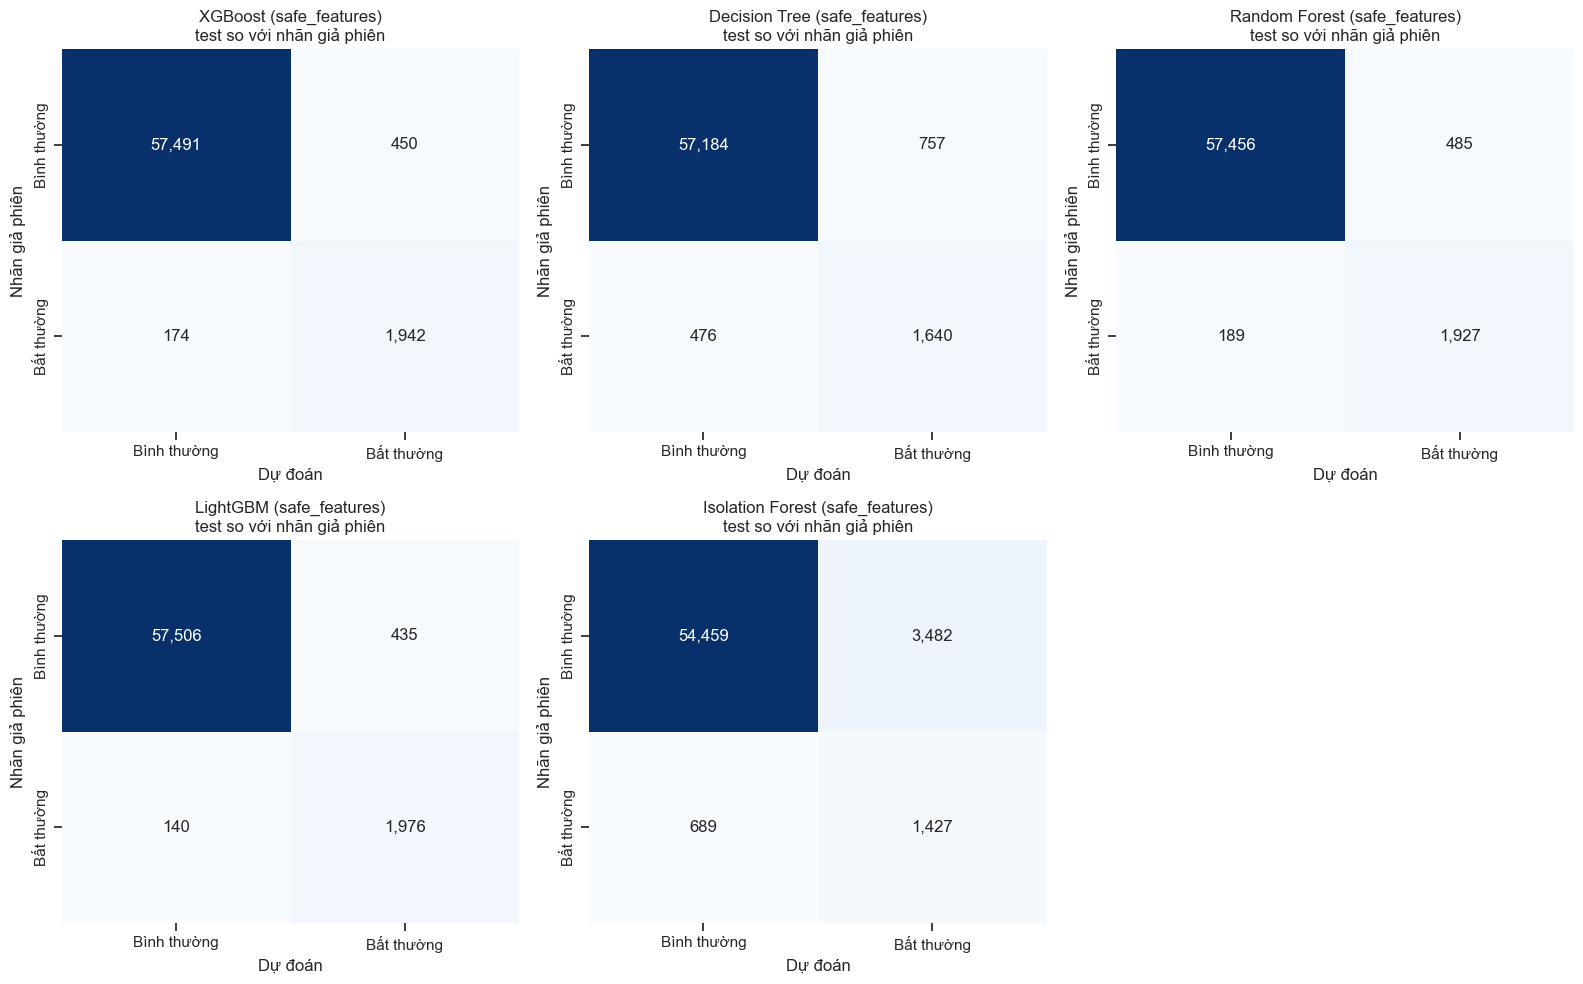

In [21]:
confusion_items = {
    key: value
    for key, value in prediction_sets.items()
    if key in [
        'XGBoost (safe_features)',
        'Decision Tree (safe_features)',
        'Random Forest (safe_features)',
        'LightGBM (safe_features)',
        'Isolation Forest (safe_features)',
    ]
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for ax, (model_name, values) in zip(axes, confusion_items.items()):
    cm = confusion_matrix(values['y_true'], values['y_pred'], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', xticklabels=['Bình thường', 'Bất thường'], yticklabels=['Bình thường', 'Bất thường'], cbar=False, ax=ax)
    ax.set_title(f'{model_name}\n{values["split"]} so với nhãn giả phiên')
    ax.set_xlabel('Dự đoán')
    ax.set_ylabel('Nhãn giả phiên')

for ax in axes[len(confusion_items):]:
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'output_group_confusion_matrices.png', dpi=160, bbox_inches='tight')
plt.show()


## 14. Session anomaly report và export

`session_anomaly_tags.csv` là bảng tag rule-level cho mọi session. `session_anomaly_report.csv` là bảng tổng hợp các session bị rule hoặc model đánh dấu.

In [22]:
model_pred_cols = ['xgboost_pred', 'decision_tree_pred', 'random_forest_pred', 'lightgbm_pred', 'isolation_forest_pred']
anomalies['model_vote_count'] = anomalies[model_pred_cols].sum(axis=1)
anomalies['is_rule_anomaly'] = anomalies['is_anomaly_rule']
anomalies['is_model_anomaly'] = (anomalies['model_vote_count'] > 0).astype(int)
anomalies['is_anomaly_final'] = ((anomalies['is_rule_anomaly'] == 1) | (anomalies['is_model_anomaly'] == 1)).astype(int)
anomalies['rule_anomaly_types'] = anomalies['anomaly_types']
anomalies['final_anomaly_reason'] = np.select(
    [
        (anomalies['is_rule_anomaly'] == 1) & (anomalies['is_model_anomaly'] == 1),
        anomalies['is_rule_anomaly'] == 1,
        anomalies['is_model_anomaly'] == 1,
    ],
    ['Business rules + ML models', 'Business rules', 'ML model-only suspicious'],
    default='Normal',
)

score_99 = anomalies['isolation_forest_score'].quantile(0.99)

def classify_severity(row):
    if row['total_flags'] >= 3 or row['model_vote_count'] >= 4 or row['isolation_forest_score'] >= score_99:
        return 'CRITICAL'
    if row['total_flags'] >= 2 or row['model_vote_count'] >= 2:
        return 'HIGH'
    if row['total_flags'] == 1 or row['model_vote_count'] == 1:
        return 'MEDIUM'
    return 'LOW'

anomalies['severity'] = anomalies.apply(classify_severity, axis=1)
severity_order = {'CRITICAL': 3, 'HIGH': 2, 'MEDIUM': 1, 'LOW': 0}
anomalies['severity_rank'] = anomalies['severity'].map(severity_order)

if not (anomalies['anomaly_type_count'] == anomalies['total_flags']).all():
    raise ValueError('anomaly_type_count phai bang total_flags truoc khi export')
if not (anomalies.loc[anomalies['is_rule_anomaly'] == 0, 'rule_anomaly_types'] == 'Normal').all():
    raise ValueError('Normal session phai co rule_anomaly_types = Normal truoc khi export')

session_anomaly_tags = anomalies[
    ['visitorid', 'session_number', 'is_anomaly', 'anomaly_types', 'anomaly_type_count', 'total_flags'] + flag_cols
].reset_index()

report_cols = [
    'visitorid', 'session_number', 'session_start', 'session_end',
    'is_anomaly_final', 'final_anomaly_reason', 'is_rule_anomaly', 'rule_anomaly_types',
    'is_model_anomaly', 'model_vote_count', 'severity', 'anomaly_type_count', 'total_flags',
    'total_events', 'unique_items', 'session_duration_sec', 'events_per_minute',
    'event_type_entropy', 'hour_entropy', 'xgboost_score', 'decision_tree_score',
    'random_forest_score', 'lightgbm_score', 'isolation_forest_score',
] + model_pred_cols + flag_cols

session_anomaly_report = (
    anomalies[anomalies['is_anomaly_final'] == 1]
    .sort_values(['severity_rank', 'model_vote_count', 'total_flags', 'isolation_forest_score'], ascending=[False, False, False, False])
    [report_cols]
    .reset_index()
)

session_anomaly_tags.to_csv(OUTPUT_DIR / 'session_anomaly_tags.csv', index=False)
session_anomaly_report.to_csv(OUTPUT_DIR / 'session_anomaly_report.csv', index=False)
metrics_df.to_csv(OUTPUT_DIR / 'group_model_metrics.csv', index=False)
leakage_audit_df.to_csv(OUTPUT_DIR / 'group_leakage_audit.csv', index=False)
anomaly_type_breakdown.to_csv(OUTPUT_DIR / 'group_anomaly_type_breakdown.csv', index=False)

print(f'So session trong anomaly report: {len(session_anomaly_report):,}')
print('Da export: session_anomaly_tags.csv')
print('Da export: session_anomaly_report.csv')
print('Da export: group_model_metrics.csv')
print('Da export: group_leakage_audit.csv')
print('Da export: group_anomaly_type_breakdown.csv')
print('\nVi du session anomaly report:')
display(session_anomaly_report.head(15))

So session trong anomaly report: 177,931
Da export: session_anomaly_tags.csv
Da export: session_anomaly_report.csv
Da export: group_model_metrics.csv
Da export: group_leakage_audit.csv
Da export: group_anomaly_type_breakdown.csv

Vi du session anomaly report:


,session_id,visitorid,session_number,session_start,session_end,is_anomaly_final,final_anomaly_reason,is_rule_anomaly,rule_anomaly_types,is_model_anomaly,...,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
0,530559_S107,530559,107,2015-07-25 15:28:17.422,2015-07-26 02:17:25.589,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
1,890980_S18,890980,18,2015-07-20 19:26:39.701,2015-07-21 00:48:45.945,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
2,1376763_S2,1376763,2,2015-07-20 19:49:40.822,2015-07-21 02:07:07.124,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
3,582933_S3,582933,3,2015-07-20 14:47:02.477,2015-07-21 02:53:26.032,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
4,152963_S48,152963,48,2015-08-20 19:05:27.399,2015-08-20 22:44:21.935,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
5,1150086_S70,1150086,70,2015-07-10 15:19:05.296,2015-07-10 19:10:50.966,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
6,438441_S3,438441,3,2015-06-03 20:37:05.477,2015-06-04 02:46:30.499,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
7,1150086_S30,1150086,30,2015-06-22 18:30:33.506,2015-06-23 01:12:00.744,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
8,861299_S14,861299,14,2015-07-28 20:09:51.405,2015-07-29 01:16:30.736,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1
9,994820_S36,994820,36,2015-09-07 15:45:41.528,2015-09-07 21:22:24.787,1,Business rules + ML models,1,"Bot scraper, Rapid-fire, Item hoarding, Sessio...",1,...,0,1,0,1,1,1,1,0,0,1


## 15. Kết luận báo cáo

- Notebook đã chuyển đơn vị phân tích chính từ `visitorid` sang `session_id` với gap 30 phút.
- Multi-label anomaly tagging hiện hoạt động ở cấp session, phù hợp hơn với hành vi web ngắn hạn như rapid-fire, sequence violation và session bomb.
- Bảng chính dùng safe session features để giảm label leakage; bảng full features chỉ dùng để minh họa rule-mimic.
- Nhóm supervised gồm XGBoost, Decision Tree, Random Forest và LightGBM; LightGBM bổ sung mô hình gradient boosting leaf-wise để so sánh với XGBoost trên dữ liệu bảng.
- Isolation Forest không dùng nhãn khi train; metric của thuật toán này là overlap với session pseudo-label.
- RetailRocket không có nhãn anomaly thật, vì vậy mọi đánh giá định lượng và multi-label tag là pseudo-label do nhóm thiết kế.

In [23]:
print('=' * 70)
print('TONG KET DO AN NHOM - SESSION LEVEL')
print('=' * 70)
print(f'Dataset: RetailRocket E-commerce events')
print(f'So event: {len(events):,}')
print(f'So visitor: {events["visitorid"].nunique():,}')
print(f'So session profile: {len(anomalies):,}')
print(f'Bat thuong theo business rules: {anomalies["is_rule_anomaly"].sum():,} ({anomalies["is_rule_anomaly"].mean() * 100:.2f}%)')
print(f'Bat thuong theo ket qua tong hop: {anomalies["is_anomaly_final"].sum():,} ({anomalies["is_anomaly_final"].mean() * 100:.2f}%)')
print('\nBang metric chinh:')
display(main_metrics_df)
print('\nBang phu full features hoc lai luat:')
display(rule_mimic_metrics_df)
print('\nBreakdown anomaly type:')
display(anomaly_type_breakdown)
print('\nVi du multi-label anomaly tagging theo session:')
display(session_anomaly_tags[session_anomaly_tags['is_anomaly'] == 1].head(10))
print('\nPhan bo muc do nghiem trong trong report:')
display(session_anomaly_report['severity'].value_counts().rename_axis('severity').reset_index(name='count'))
print('\nGhi chu bao cao: su dung bang safe_features lam metric chinh; full_features chi minh hoa leakage/rule-mimic.')

TONG KET DO AN NHOM - SESSION LEVEL
Dataset: RetailRocket E-commerce events
So event: 2,755,641
So visitor: 1,407,580
So session profile: 1,761,675
Bat thuong theo business rules: 61,849 (3.51%)
Bat thuong theo ket qua tong hop: 177,931 (10.10%)

Bang metric chinh:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
0,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,validation,0.5000,0.9333,0.0455,0.0452,0.0454,0.5054,0.0355,2102,2087
1,Dummy baseline,safe_features,Baseline so với nhãn giả phiên,test,0.5000,0.9327,0.0406,0.0402,0.0404,0.5027,0.0354,2116,2095
2,XGBoost,safe_features,Main supervised so với nhãn giả phiên,validation,0.8693,0.9901,0.8138,0.9291,0.8676,0.9941,0.9284,2102,2400
3,XGBoost,safe_features,Main supervised so với nhãn giả phiên,test,0.8693,0.9896,0.8119,0.9178,0.8616,0.9927,0.9220,2116,2392
4,Decision Tree,safe_features,Main supervised so với nhãn giả phiên,validation,0.9484,0.9812,0.7029,0.8026,0.7494,0.9884,0.7663,2102,2400
5,Decision Tree,safe_features,Main supervised so với nhãn giả phiên,test,0.9484,0.9795,0.6842,0.7750,0.7268,0.9871,0.7470,2116,2397
6,Random Forest,safe_features,Main supervised so với nhãn giả phiên,validation,0.8477,0.9894,0.8050,0.9191,0.8583,0.9929,0.9118,2102,2400
7,Random Forest,safe_features,Main supervised so với nhãn giả phiên,test,0.8477,0.9888,0.7989,0.9107,0.8511,0.9922,0.9019,2116,2412
8,LightGBM,safe_features,Main supervised so với nhãn giả phiên,validation,0.8664,0.9910,0.8250,0.9420,0.8796,0.9953,0.9418,2102,2400
9,LightGBM,safe_features,Main supervised so với nhãn giả phiên,test,0.8664,0.9904,0.8196,0.9338,0.8730,0.9944,0.9345,2116,2411



Bang phu full features hoc lai luat:


,model,feature_set,evaluation_type,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,support_anomaly,predicted_anomaly
10,XGBoost,full_features,Rule-mimic / agreement with session business r...,validation,0.5000,0.9995,0.9887,0.9986,0.9936,1.0000,0.9998,2102,2123
11,XGBoost,full_features,Rule-mimic / agreement with session business r...,test,0.5000,0.9996,0.9892,0.9995,0.9944,1.0000,0.9999,2116,2138
12,LightGBM,full_features,Rule-mimic / agreement with session business r...,validation,0.5000,0.9998,0.9976,0.9981,0.9979,1.0000,0.9999,2102,2103
13,LightGBM,full_features,Rule-mimic / agreement with session business r...,test,0.5000,0.9999,0.9981,0.9991,0.9986,1.0000,0.9999,2116,2118
14,Decision Tree,full_features,Rule-mimic / agreement with session business r...,validation,1.0000,0.9981,1.0000,0.9472,0.9729,0.9992,0.9958,2102,1991
15,Decision Tree,full_features,Rule-mimic / agreement with session business r...,test,1.0000,0.9978,1.0000,0.9386,0.9683,0.9997,0.9963,2116,1986
16,Random Forest,full_features,Rule-mimic / agreement with session business r...,validation,0.5158,0.9949,0.8743,0.9990,0.9325,0.9999,0.9973,2102,2402
17,Random Forest,full_features,Rule-mimic / agreement with session business r...,test,0.5158,0.9943,0.8615,0.9995,0.9254,0.9999,0.9960,2116,2455



Breakdown anomaly type:


...


Vi du multi-label anomaly tagging theo session:


,session_id,visitorid,session_number,is_anomaly,anomaly_types,anomaly_type_count,total_flags,flag_BR01_bot_scraper,flag_BR02_ghost_buyer,flag_BR03_click_fraud,flag_BR04_rapid_fire,flag_BR05_night_crawler,flag_BR06_item_hoarding,flag_BR07_session_bomb,flag_BR08_sequence_violation,flag_BR09_transaction_burst,flag_BR10_cart_abandonment,flag_BR11_repeated_view_spam,flag_BR12_category_scanning
2,2_S1,2,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
63,51_S1,51,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
66,54_S1,54,1,1,Click fraud,1,1,0,0,1,0,0,0,0,0,0,0,0,0
140,97_S1,97,1,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
218,162_S1,162,1,1,Night crawler,1,1,0,0,0,0,1,0,0,0,0,0,0,0
234,172_S2,172,2,1,"Bot scraper, Click fraud, Night crawler, Sessi...",4,4,1,0,1,0,1,0,1,0,0,0,0,0
235,172_S3,172,3,1,"Click fraud, Night crawler",2,2,0,0,1,0,1,0,0,0,0,0,0,0
236,172_S4,172,4,1,"Bot scraper, Rapid-fire, Night crawler, Item h...",4,4,1,0,0,1,1,1,0,0,0,0,0,0
293,224_S1,224,1,1,"Bot scraper, Click fraud, Night crawler",3,3,1,0,1,0,1,0,0,0,0,0,0,0
336,264_S1,264,1,1,Rapid-fire,1,1,0,0,0,1,0,0,0,0,0,0,0,0



Phan bo muc do nghiem trong trong report:


,severity,count
0,MEDIUM,90595
1,CRITICAL,68918
2,HIGH,18418



Ghi chu bao cao: su dung bang safe_features lam metric chinh; full_features chi minh hoa leakage/rule-mimic.
